# Fase 6 — Positional Frequency Chaos Game Representation (PFCGR)

Viene valutata una rappresentazione estesa della FCGR: la **Positional Frequency Chaos Game Representation (PFCGR)**.

La FCGR standard rappresenta la frequenza dei k-mer, ma non conserva informazioni sulla posizione in cui essi compaiono lungo la sequenza.
La PFCGR aggiunge quattro statistiche relative alle posizioni delle occorrenze di ciascun k-mer:

1. frequenza;
2. posizione media;
3. deviazione standard delle posizioni;
4. skewness delle posizioni;
5. kurtosis delle posizioni.

Per un valore di `k`, ogni statistica viene organizzata utilizzando la
stessa geometria `2^k × 2^k` della FCGR.

Con `k = 5`, quindi, una sequenza non sarà più rappresentata da una
matrice `1 × 32 × 32`, ma da una rappresentazione multicanale
`5 × 32 × 32`.

L'obiettivo è confrontare direttamente:

- FCGR standard + CNN
- PFCGR + CNN

mantenendo invariati dataset, split, k-mer size e protocollo di training.

In [1]:
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report
)

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [4]:
import os

# Necessario per operazioni CUDA deterministiche
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

In [5]:
K = 5
SIZE = 2 ** K

CHANNEL_NAMES = [
    "frequency",
    "mean_position",
    "std_position",
    "skewness_position",
    "kurtosis_position"
]

print("k:", K)
print("PFCGR shape:", (len(CHANNEL_NAMES), SIZE, SIZE))

k: 5
PFCGR shape: (5, 32, 32)


coordinate fcgr di un kmer

In [6]:
CORNERS = {
    "A": (0.0, 1.0),
    "C": (0.0, 0.0),
    "G": (1.0, 0.0),
    "T": (1.0, 1.0)
}


def kmer_to_fcgr_coordinates(kmer):

    size = 2 ** len(kmer)

    x = 0.5
    y = 0.5

    for base in kmer:

        if base not in CORNERS:
            return None

        cx, cy = CORNERS[base]

        x = (x + cx) * 0.5
        y = (y + cy) * 0.5

    col = min(
        int(x * size),
        size - 1
    )

    row = min(
        int(y * size),
        size - 1
    )

    return row, col

In [7]:
# smoke test

for base in ["A", "C", "G", "T"]:
    print(
        base,
        kmer_to_fcgr_coordinates(base)
    )

A (1, 0)
C (0, 0)
G (0, 1)
T (1, 1)


min-max normalization

In [8]:
def minmax_normalize_masked(
    matrix,
    valid_mask
):

    matrix = np.asarray(
        matrix,
        dtype=np.float32
    )

    valid_mask = np.asarray(
        valid_mask,
        dtype=bool
    )

    result = np.zeros_like(
        matrix,
        dtype=np.float32
    )

    if not np.any(valid_mask):
        return result

    values = matrix[
        valid_mask
    ]

    min_value = values.min()
    max_value = values.max()

    if max_value == min_value:

        if max_value != 0:
            result[
                valid_mask
            ] = 1.0

        return result

    result[
        valid_mask
    ] = (
        values - min_value
    ) / (
        max_value - min_value
    )

    return result

In [9]:
def normalize_fcgr_relative(fcgr):

    total = fcgr.sum()

    if total == 0:
        return fcgr.astype(
            np.float32
        )

    return (
        fcgr.astype(np.float32)
        / total
    )

Prima implementazione PFCGR

In [10]:
def compute_pfcgr_reference(
    sequence,
    k=5
):

    sequence = sequence.upper()

    size = 2 ** k

    positions = defaultdict(list)

    n_windows = (
        len(sequence)
        - k
        + 1
    )

    for i in range(
        max(0, n_windows)
    ):

        kmer = sequence[
            i:i+k
        ]

        if any(
            base not in CORNERS
            for base in kmer
        ):
            continue

        positions[kmer].append(i)

    # --------------------------------------------------
    # Raw matrices
    # --------------------------------------------------

    frequency = np.zeros(
        (size, size),
        dtype=np.float32
    )

    mean_pos = np.zeros_like(
        frequency
    )

    std_pos = np.zeros_like(
        frequency
    )

    skew_pos = np.zeros_like(
        frequency
    )

    kurt_pos = np.zeros_like(
        frequency
    )

    # --------------------------------------------------
    # Validity masks
    # --------------------------------------------------

    frequency_mask = np.zeros(
        (size, size),
        dtype=bool
    )

    mean_mask = np.zeros_like(
        frequency_mask
    )

    std_mask = np.zeros_like(
        frequency_mask
    )

    skew_mask = np.zeros_like(
        frequency_mask
    )

    kurt_mask = np.zeros_like(
        frequency_mask
    )

    # --------------------------------------------------
    # Statistics
    # --------------------------------------------------

    for kmer, pos_list in positions.items():

        row, col = (
            kmer_to_fcgr_coordinates(
                kmer
            )
        )

        values = np.asarray(
            pos_list,
            dtype=np.float64
        )

        n = len(values)

        # Frequency
        frequency[
            row,
            col
        ] = n

        frequency_mask[
            row,
            col
        ] = True

        # Mean
        mean_pos[
            row,
            col
        ] = values.mean()

        mean_mask[
            row,
            col
        ] = True

        # Standard deviation
        if n >= 2:

            std_pos[
                row,
                col
            ] = values.std(
                ddof=0
            )

            std_mask[
                row,
                col
            ] = True

        # Skewness
        if (
            n >= 3
            and np.std(values) > 0
        ):

            skew_value = skew(
                values,
                bias=True
            )

            if np.isfinite(
                skew_value
            ):

                skew_pos[
                    row,
                    col
                ] = skew_value

                skew_mask[
                    row,
                    col
                ] = True

        # Kurtosis
        if (
            n >= 4
            and np.std(values) > 0
        ):

            kurt_value = kurtosis(
                values,
                fisher=True,
                bias=True
            )

            if np.isfinite(
                kurt_value
            ):

                kurt_pos[
                    row,
                    col
                ] = kurt_value

                kurt_mask[
                    row,
                    col
                ] = True

    # --------------------------------------------------
    # Mask-aware normalization
    # --------------------------------------------------

    frequency_norm = normalize_fcgr_relative(
        frequency
    )

    mean_norm = (
        minmax_normalize_masked(
            mean_pos,
            mean_mask
        )
    )

    std_norm = (
        minmax_normalize_masked(
            std_pos,
            std_mask
        )
    )

    skew_norm = (
        minmax_normalize_masked(
            skew_pos,
            skew_mask
        )
    )

    kurt_norm = (
        minmax_normalize_masked(
            kurt_pos,
            kurt_mask
        )
    )

    pfcgr = np.stack(
        [
            frequency_norm,
            mean_norm,
            std_norm,
            skew_norm,
            kurt_norm
        ],
        axis=0
    )

    return pfcgr

test con una sequenza artificiale

In [11]:
test_sequence = (
    "ACGTACGTACGT"
    "AAAAACCCCC"
    "GGGGGTTTTT"
    "ACGTACGT"
)

print(
    "Sequence length:",
    len(test_sequence)
)

test_pfcgr = compute_pfcgr_reference(
    test_sequence,
    k=K
)

print(
    "PFCGR shape:",
    test_pfcgr.shape
)

print(
    "dtype:",
    test_pfcgr.dtype
)

print(
    "min:",
    test_pfcgr.min()
)

print(
    "max:",
    test_pfcgr.max()
)

print()

for i, name in enumerate(
    CHANNEL_NAMES
):

    channel = test_pfcgr[i]

    print(
        f"{name:20s} | "
        f"min={channel.min():.4f} | "
        f"max={channel.max():.4f} | "
        f"nonzero="
        f"{np.count_nonzero(channel)}"
    )

Sequence length: 40
PFCGR shape: (5, 32, 32)
dtype: float32
min: 0.0
max: 1.0

frequency            | min=0.0000 | max=0.1111 | nonzero=26
mean_position        | min=0.0000 | max=1.0000 | nonzero=25
std_position         | min=0.0000 | max=1.0000 | nonzero=3
skewness_position    | min=0.0000 | max=1.0000 | nonzero=3
kurtosis_position    | min=0.0000 | max=1.0000 | nonzero=1


In [12]:
for i, name in enumerate(
    CHANNEL_NAMES
):

    channel = test_pfcgr[i]

    print(
        f"{name:20s} | "
        f"min={channel.min():.4f} | "
        f"max={channel.max():.4f} | "
        f"nonzero="
        f"{np.count_nonzero(channel)}"
    )

frequency            | min=0.0000 | max=0.1111 | nonzero=26
mean_position        | min=0.0000 | max=1.0000 | nonzero=25
std_position         | min=0.0000 | max=1.0000 | nonzero=3
skewness_position    | min=0.0000 | max=1.0000 | nonzero=3
kurtosis_position    | min=0.0000 | max=1.0000 | nonzero=1


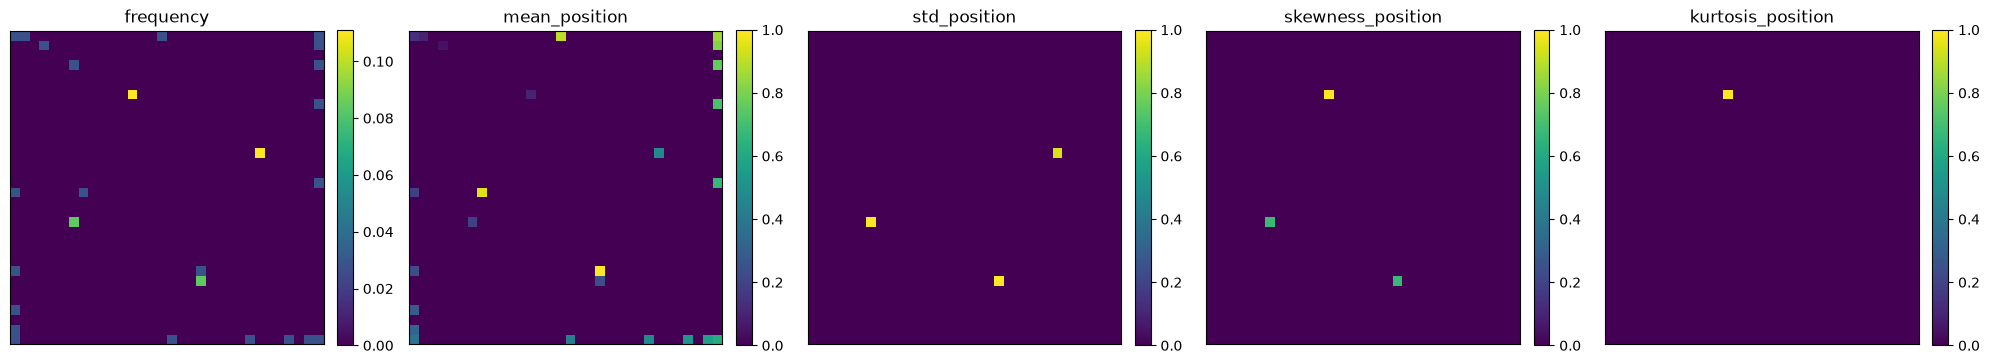

In [13]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4)
)

for i, (
    ax,
    name
) in enumerate(
    zip(
        axes,
        CHANNEL_NAMES
    )
):

    im = ax.imshow(
        test_pfcgr[i],
        origin="lower",
        interpolation="nearest"
    )

    ax.set_title(
        name
    )

    ax.set_xticks([])
    ax.set_yticks([])

    plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

plt.tight_layout()
plt.show()

Confronto FCGR e PFCGR

In [14]:
def compute_fcgr_counts(
    sequence,
    k
):

    sequence = sequence.upper()

    size = 2 ** k

    fcgr = np.zeros(
        (size, size),
        dtype=np.float32
    )

    for i in range(
        len(sequence) - k + 1
    ):

        kmer = sequence[
            i:i+k
        ]

        if any(
            base not in CORNERS
            for base in kmer
        ):
            continue

        row, col = (
            kmer_to_fcgr_coordinates(
                kmer
            )
        )

        fcgr[
            row,
            col
        ] += 1

    return fcgr

In [15]:
standard_fcgr = compute_fcgr_counts(
    test_sequence,
    K
)

standard_fcgr_norm = (
    normalize_fcgr_relative(
        standard_fcgr
    )
)

frequency_channel = (
    test_pfcgr[0]
)

print(
    "Same frequency channel:",
    np.allclose(
        standard_fcgr_norm,
        frequency_channel
    )
)

print(
    "Maximum difference:",
    np.abs(
        standard_fcgr_norm
        - frequency_channel
    ).max()
)

Same frequency channel: True
Maximum difference: 0.0


Caricamento metadata e fasta

In [16]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

METADATA_PATH = (
    PROCESSED_DIR
    / "eccdna_metadata_clean.tsv"
)

FASTA_PATH = (
    RAW_DIR
    / "eccdna_disease_detection.body.fa"
)

metadata = pd.read_csv(
    METADATA_PATH,
    sep="\t",
    low_memory=False
)

print("Metadata:", metadata.shape)

Metadata: (3755079, 26)


In [17]:
CLASSES = [
    "healthy",
    "gastric cancer",
    "ovarian cancer",
    "prostate cancer",
    "colorectal cancer"
]

test selezionando 2 sequenze per classe

In [18]:
real_test_df = (
    metadata[
        (metadata["disease_clean"].isin(CLASSES))
        & (metadata["split_cluster"] == "train")
        & (metadata["length"] >= 500)
    ]
    .groupby(
        "disease_clean",
        group_keys=False
    )
    .sample(
        n=2,
        random_state=42
    )
    .reset_index(drop=True)
)

print(
    real_test_df[
        [
            "id",
            "disease_clean",
            "length",
            "source_db",
            "tissue"
        ]
    ]
)

                       id      disease_clean  length     source_db  \
0  CircleBaseV2_002942180  colorectal cancer     544  CircleBaseV2   
1  CircleBaseV2_002915785  colorectal cancer    1210  CircleBaseV2   
2  CircleBaseV2_001563721     gastric cancer     727  CircleBaseV2   
3  CircleBaseV2_001413237     gastric cancer     836  CircleBaseV2   
4  CircleBaseV2_002790222            healthy    3724  CircleBaseV2   
5    eccDNABase_000699301            healthy    7603    eccDNABase   
6    eccDNABase_000229396     ovarian cancer     615    eccDNABase   
7    eccDNABase_000188683     ovarian cancer    1355    eccDNABase   
8    eccDNABase_000399867    prostate cancer     886    eccDNABase   
9    eccDNABase_000130788    prostate cancer    1107    eccDNABase   

                    tissue  
0  Colorectal tumor tissue  
1  Colorectal tumor tissue  
2                  Stomach  
3                  Stomach  
4                   Muscle  
5        Plasma leukocytes  
6                   OVCAR8

In [19]:
def load_fasta_sequences(
    fasta_path,
    target_ids
):

    target_ids = set(
        map(str, target_ids)
    )

    sequences = {}

    current_id = None
    current_sequence = []

    with open(
        fasta_path,
        "r"
    ) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):

                if (
                    current_id is not None
                    and current_id in target_ids
                ):

                    sequences[current_id] = (
                        "".join(
                            current_sequence
                        )
                    )

                    if (
                        len(sequences)
                        == len(target_ids)
                    ):
                        break

                header = line[1:]

                current_id = (
                    header
                    .split("|", 1)[0]
                    .strip()
                )

                current_sequence = []

            else:

                if current_id in target_ids:

                    current_sequence.append(
                        line
                    )

        if (
            current_id is not None
            and current_id in target_ids
            and current_id not in sequences
        ):

            sequences[current_id] = (
                "".join(
                    current_sequence
                )
            )

    return sequences

In [20]:
real_ids = (
    real_test_df["id"]
    .astype(str)
    .tolist()
)

real_sequences = (
    load_fasta_sequences(
        FASTA_PATH,
        real_ids
    )
)

print(
    "Requested:",
    len(real_ids)
)

print(
    "Loaded:",
    len(real_sequences)
)

Requested: 10
Loaded: 10


In [21]:
# analisi pfcgr reale

pfcgr_diagnostics = []

real_pfcgrs = {}

for _, row in real_test_df.iterrows():

    seq_id = str(
        row["id"]
    )

    sequence = real_sequences[
        seq_id
    ]

    pfcgr = compute_pfcgr_reference(
        sequence,
        k=K
    )

    real_pfcgrs[
        seq_id
    ] = pfcgr

    diagnostic = {
        "id": seq_id,
        "disease": row["disease_clean"],
        "length": len(sequence)
    }

    for channel_idx, channel_name in enumerate(
        CHANNEL_NAMES
    ):

        channel = pfcgr[
            channel_idx
        ]

        diagnostic[
            f"{channel_name}_nonzero"
        ] = np.count_nonzero(
            channel
        )

    pfcgr_diagnostics.append(
        diagnostic
    )

pfcgr_diagnostics_df = pd.DataFrame(
    pfcgr_diagnostics
)

pfcgr_diagnostics_df

,id,disease,length,frequency_nonzero,mean_position_nonzero,std_position_nonzero,skewness_position_nonzero,kurtosis_position_nonzero
0,CircleBaseV2_002942180,colorectal cancer,544,319,318,126,58,22
1,CircleBaseV2_002915785,colorectal cancer,1210,586,585,315,160,69
2,CircleBaseV2_001563721,gastric cancer,727,482,481,177,50,8
3,CircleBaseV2_001413237,gastric cancer,836,489,488,199,72,27
4,CircleBaseV2_002790222,healthy,3724,833,832,678,555,425
5,eccDNABase_000699301,healthy,7603,916,915,822,759,710
6,eccDNABase_000229396,ovarian cancer,615,372,371,147,58,25
7,eccDNABase_000188683,ovarian cancer,1355,655,654,381,190,81
8,eccDNABase_000399867,prostate cancer,886,492,491,218,107,42
9,eccDNABase_000130788,prostate cancer,1107,575,574,294,135,59


In [22]:
# percentuale celle informative

diagnostics_percentage = (
    pfcgr_diagnostics_df.copy()
)

for channel_name in CHANNEL_NAMES:

    col = (
        f"{channel_name}_nonzero"
    )

    diagnostics_percentage[
        f"{channel_name}_pct"
    ] = (
        diagnostics_percentage[col]
        / (SIZE * SIZE)
        * 100
    )

diagnostics_percentage[
    [
        "disease",
        "length",
        "frequency_pct",
        "mean_position_pct",
        "std_position_pct",
        "skewness_position_pct",
        "kurtosis_position_pct"
    ]
]

,disease,length,frequency_pct,mean_position_pct,std_position_pct,skewness_position_pct,kurtosis_position_pct
0,colorectal cancer,544,31.152344,31.054688,12.304688,5.664062,2.148438
1,colorectal cancer,1210,57.226562,57.128906,30.761719,15.625000,6.738281
2,gastric cancer,727,47.070312,46.972656,17.285156,4.882812,0.781250
3,gastric cancer,836,47.753906,47.656250,19.433594,7.031250,2.636719
4,healthy,3724,81.347656,81.250000,66.210938,54.199219,41.503906
5,healthy,7603,89.453125,89.355469,80.273438,74.121094,69.335938
6,ovarian cancer,615,36.328125,36.230469,14.355469,5.664062,2.441406
7,ovarian cancer,1355,63.964844,63.867188,37.207031,18.554688,7.910156
8,prostate cancer,886,48.046875,47.949219,21.289062,10.449219,4.101562
9,prostate cancer,1107,56.152344,56.054688,28.710938,13.183594,5.761719


In [23]:
one_per_class = (
    real_test_df
    .groupby(
        "disease_clean",
        group_keys=False
    )
    .head(1)
)

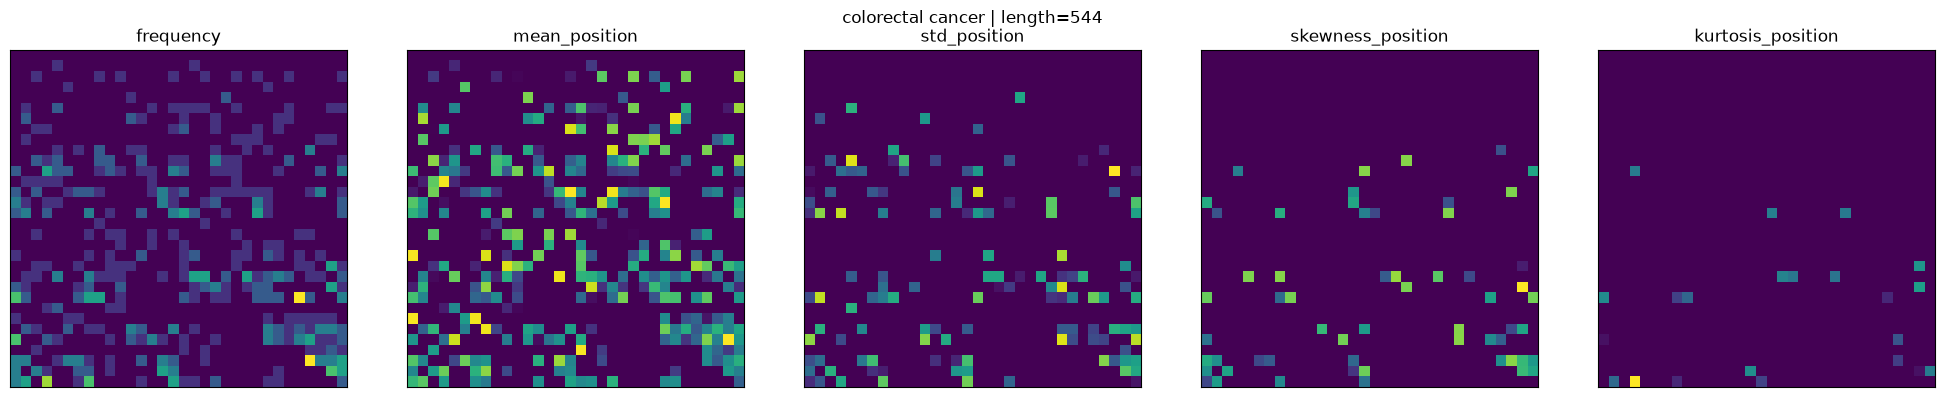

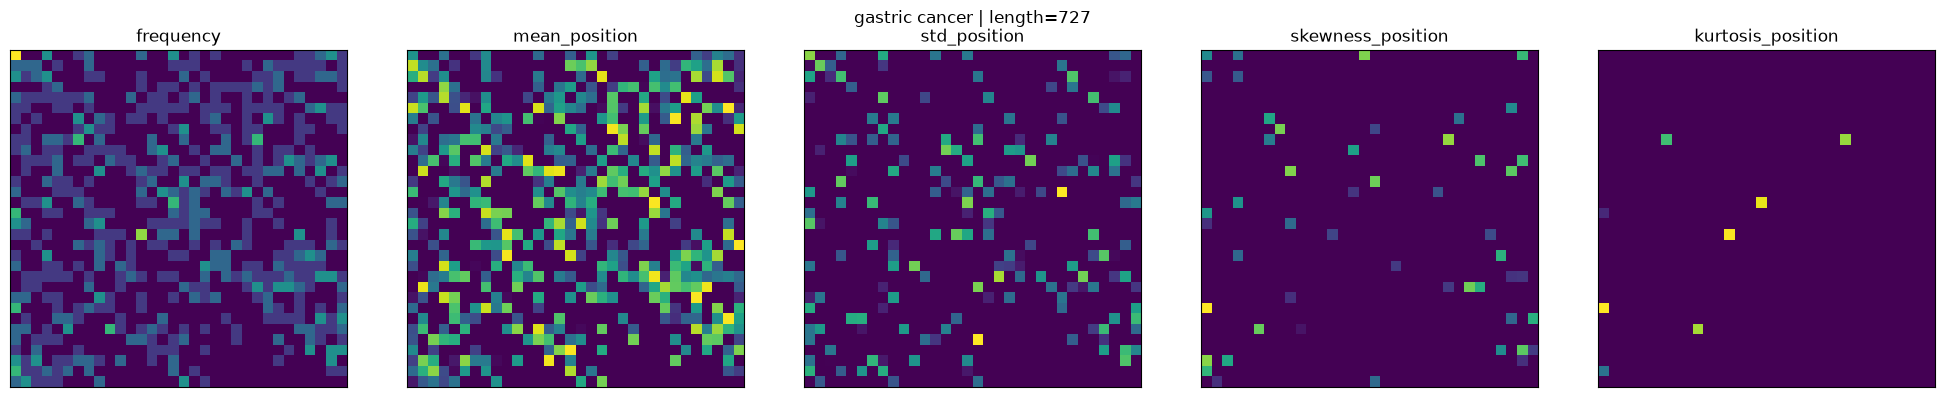

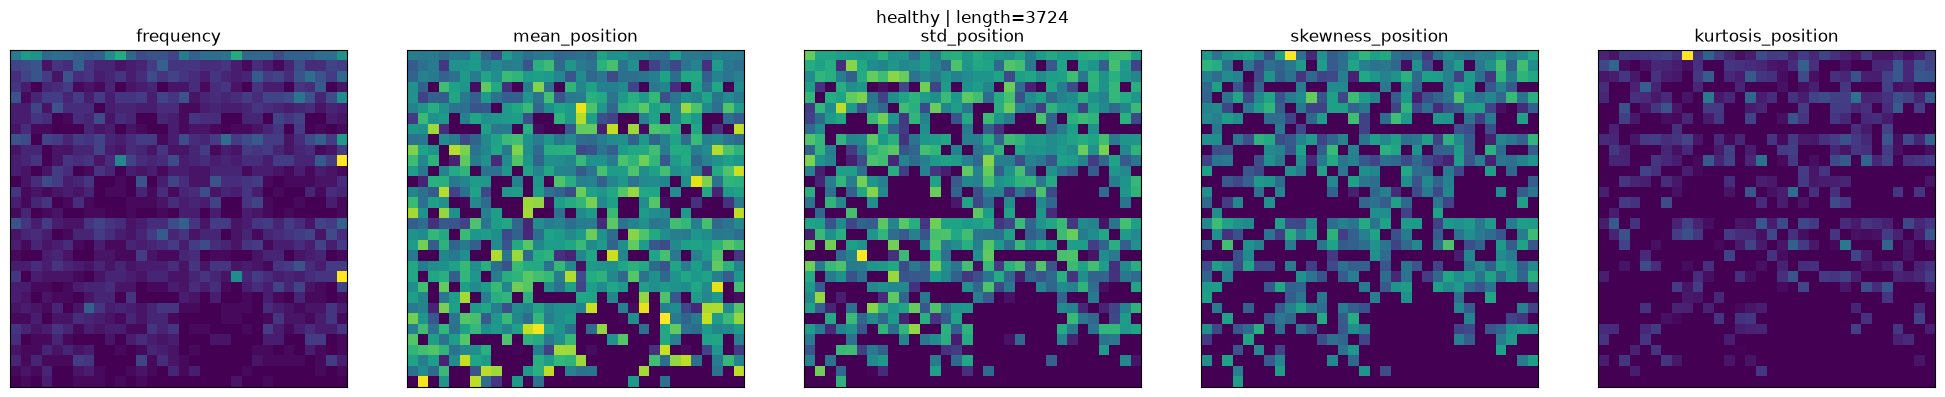

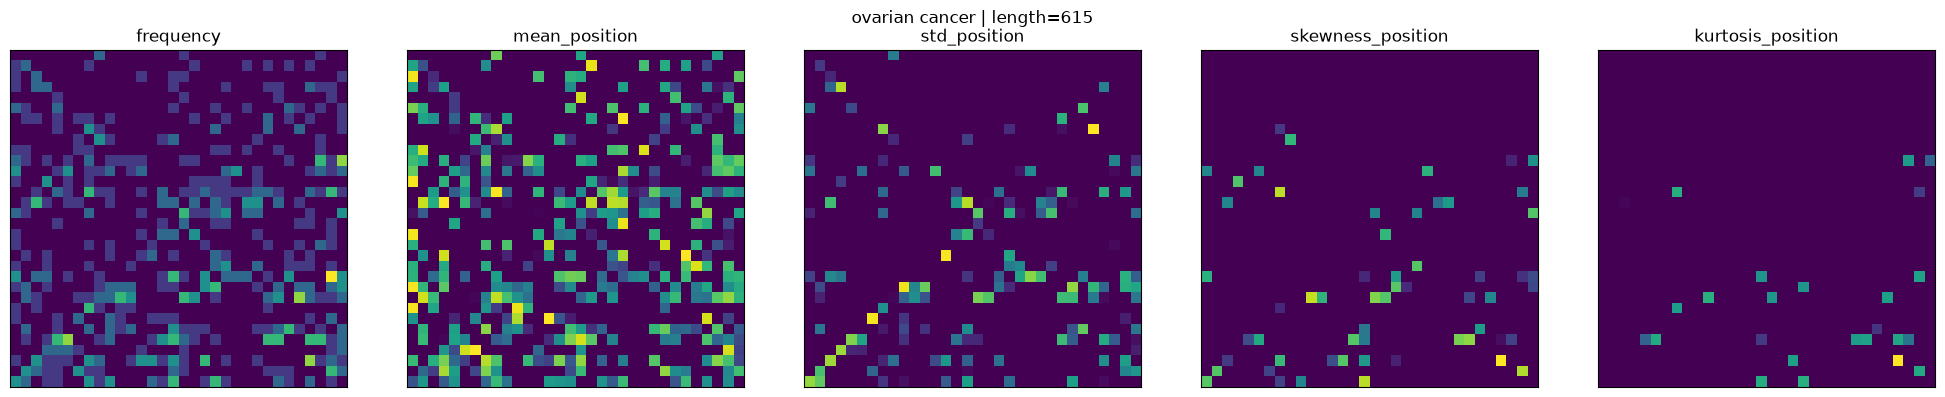

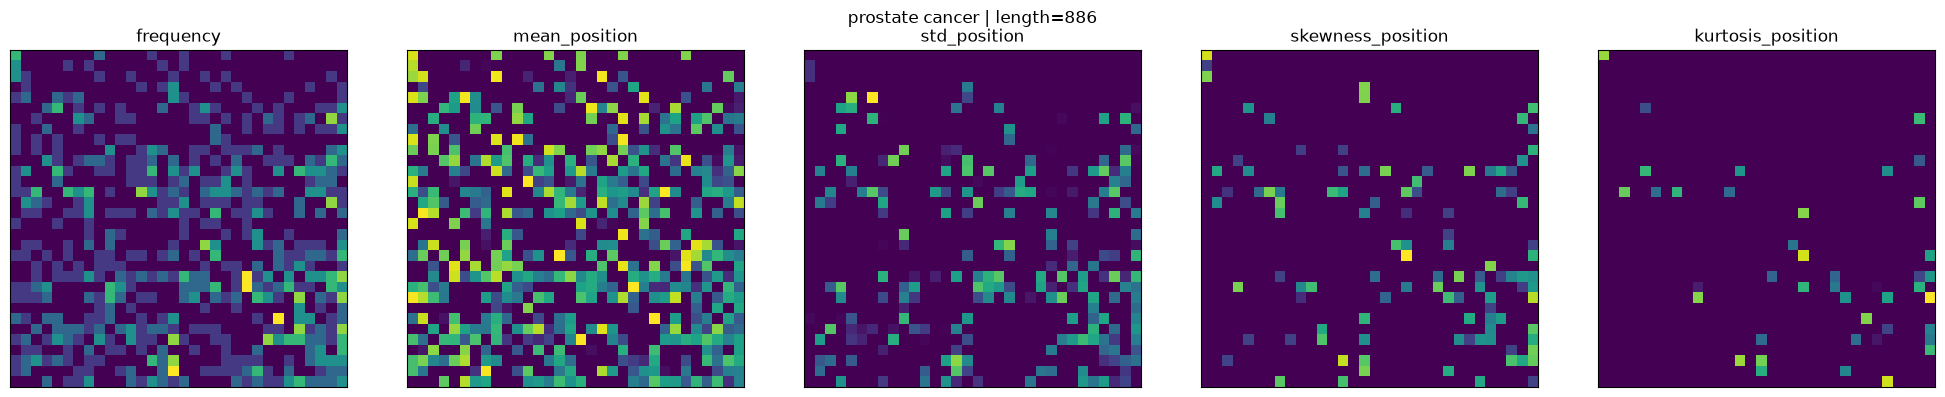

In [24]:
for _, row in one_per_class.iterrows():

    seq_id = str(
        row["id"]
    )

    disease = (
        row["disease_clean"]
    )

    pfcgr = real_pfcgrs[
        seq_id
    ]

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(20, 4)
    )

    for i, (
        ax,
        channel_name
    ) in enumerate(
        zip(
            axes,
            CHANNEL_NAMES
        )
    ):

        im = ax.imshow(
            pfcgr[i],
            origin="lower",
            interpolation="nearest"
        )

        ax.set_title(
            channel_name
        )

        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        f"{disease} | "
        f"length={row['length']}"
    )

    plt.tight_layout()
    plt.show()

analisi confondenti

In [25]:
SEED = 42

N_TRAIN_PER_CLASS = 10_000
N_VAL_PER_CLASS = 2_000

multiclass_df = metadata[
    metadata["disease_clean"].isin(CLASSES)
].copy()

train_df = multiclass_df[
    multiclass_df["split_cluster"] == "train"
].copy()

val_df = multiclass_df[
    multiclass_df["split_cluster"] == "val"
].copy()

train_balanced = (
    train_df
    .groupby(
        "disease_clean",
        group_keys=False
    )
    .sample(
        n=N_TRAIN_PER_CLASS,
        random_state=SEED
    )
    .reset_index(drop=True)
)

val_balanced = (
    val_df
    .groupby(
        "disease_clean",
        group_keys=False
    )
    .sample(
        n=N_VAL_PER_CLASS,
        random_state=SEED
    )
    .reset_index(drop=True)
)

print(train_balanced["disease_clean"].value_counts())
print()
print(val_balanced["disease_clean"].value_counts())

disease_clean
colorectal cancer    10000
gastric cancer       10000
healthy              10000
ovarian cancer       10000
prostate cancer      10000
Name: count, dtype: int64

disease_clean
colorectal cancer    2000
gastric cancer       2000
healthy              2000
ovarian cancer       2000
prostate cancer      2000
Name: count, dtype: int64


In [26]:
CLASS_TO_IDX = {
    class_name: idx
    for idx, class_name in enumerate(CLASSES)
}

train_balanced["label"] = (
    train_balanced["disease_clean"]
    .map(CLASS_TO_IDX)
)

val_balanced["label"] = (
    val_balanced["disease_clean"]
    .map(CLASS_TO_IDX)
)

In [27]:
# lunghezza

X_train_length = np.log1p(
    train_balanced[["length"]].to_numpy(
        dtype=np.float32
    )
)

X_val_length = np.log1p(
    val_balanced[["length"]].to_numpy(
        dtype=np.float32
    )
)

y_train = train_balanced[
    "label"
].to_numpy()

y_val = val_balanced[
    "label"
].to_numpy()

In [28]:
length_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

length_model.fit(
    X_train_length,
    y_train
)

length_pred = length_model.predict(
    X_val_length
)

In [29]:
print(
    "Length-only accuracy:",
    accuracy_score(
        y_val,
        length_pred
    )
)

print(
    "Length-only macro F1:",
    f1_score(
        y_val,
        length_pred,
        average="macro"
    )
)

print(
    "Length-only balanced accuracy:",
    balanced_accuracy_score(
        y_val,
        length_pred
    )
)

Length-only accuracy: 0.3015
Length-only macro F1: 0.26860891677959275
Length-only balanced accuracy: 0.3015


In [30]:
print(
    classification_report(
        y_val,
        length_pred,
        target_names=CLASSES,
        digits=4
    )
)

                   precision    recall  f1-score   support

          healthy     0.0782    0.0525    0.0628      2000
   gastric cancer     0.3235    0.4785    0.3860      2000
   ovarian cancer     0.4134    0.6265    0.4981      2000
  prostate cancer     0.2375    0.2560    0.2464      2000
colorectal cancer     0.3672    0.0940    0.1497      2000

         accuracy                         0.3015     10000
        macro avg     0.2840    0.3015    0.2686     10000
     weighted avg     0.2840    0.3015    0.2686     10000



In [31]:
# source db

X_train_source = (
    train_balanced[
        ["source_db"]
    ]
)

X_val_source = (
    val_balanced[
        ["source_db"]
    ]
)

In [32]:
source_model = Pipeline([
    (
        "preprocessor",
        ColumnTransformer([
            (
                "source",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                ["source_db"]
            )
        ])
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

In [33]:
source_model.fit(
    X_train_source,
    y_train
)

source_pred = source_model.predict(
    X_val_source
)

In [34]:
print(
    "Source-only accuracy:",
    accuracy_score(
        y_val,
        source_pred
    )
)

print(
    "Source-only macro F1:",
    f1_score(
        y_val,
        source_pred,
        average="macro"
    )
)

print(
    "Source-only balanced accuracy:",
    balanced_accuracy_score(
        y_val,
        source_pred
    )
)

Source-only accuracy: 0.3972
Source-only macro F1: 0.22705714170696178
Source-only balanced accuracy: 0.39720000000000005


In [35]:
print(
    classification_report(
        y_val,
        source_pred,
        target_names=CLASSES,
        digits=4
    )
)

                   precision    recall  f1-score   support

          healthy     0.0000    0.0000    0.0000      2000
   gastric cancer     0.3859    0.9875    0.5549      2000
   ovarian cancer     0.4091    0.9985    0.5804      2000
  prostate cancer     0.0000    0.0000    0.0000      2000
colorectal cancer     0.0000    0.0000    0.0000      2000

         accuracy                         0.3972     10000
        macro avg     0.1590    0.3972    0.2271     10000
     weighted avg     0.1590    0.3972    0.2271     10000



c:\Users\simon\miniforge3\envs\eccdna_fcgr\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\simon\miniforge3\envs\eccdna_fcgr\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\simon\miniforge3\envs\eccdna_fcgr\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [36]:
# sourcedb + legnht

X_train_conf = (
    train_balanced[
        [
            "length",
            "source_db"
        ]
    ]
    .copy()
)

X_val_conf = (
    val_balanced[
        [
            "length",
            "source_db"
        ]
    ]
    .copy()
)

In [37]:
confounder_preprocessor = (
    ColumnTransformer([
        (
            "length",
            StandardScaler(),
            ["length"]
        ),
        (
            "source",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            ["source_db"]
        )
    ])
)

In [38]:
confounder_model = Pipeline([
    (
        "preprocessor",
        confounder_preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

In [39]:
confounder_model.fit(
    X_train_conf,
    y_train
)

confounder_pred = (
    confounder_model.predict(
        X_val_conf
    )
)

In [40]:
print(
    "Length + source accuracy:",
    accuracy_score(
        y_val,
        confounder_pred
    )
)

print(
    "Length + source macro F1:",
    f1_score(
        y_val,
        confounder_pred,
        average="macro"
    )
)

print(
    "Length + source balanced accuracy:",
    balanced_accuracy_score(
        y_val,
        confounder_pred
    )
)

Length + source accuracy: 0.4654
Length + source macro F1: 0.4308906714326106
Length + source balanced accuracy: 0.4654


## Baseline non lineare sui confondenti

La Logistic Regression basata esclusivamente su `length` e `source_db`
ha ottenuto prestazioni relativamente elevate rispetto alla CNN basata
sulle FCGR.

Per verificare se la relazione tra questi confondenti e la disease sia
anche non lineare, viene utilizzato un Random Forest classifier.

In questo esperimento il modello non riceve alcuna informazione relativa
alla sequenza o alla FCGR.

In [41]:
from sklearn.ensemble import RandomForestClassifier
import time

In [42]:
rf_preprocessor = ColumnTransformer([
    (
        "source",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        ["source_db"]
    )
],
remainder="passthrough")

In [43]:
rf_confounder_model = Pipeline([
    (
        "preprocessor",
        rf_preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=10,
            random_state=SEED,
            n_jobs=-1
        )
    )
])

In [44]:
start = time.time()

rf_confounder_model.fit(
    X_train_conf,
    y_train
)

elapsed = time.time() - start

print(
    f"Training time: {elapsed:.1f}s"
)

Training time: 1.1s


In [45]:
rf_confounder_pred = (
    rf_confounder_model.predict(
        X_val_conf
    )
)

In [46]:
rf_accuracy = accuracy_score(
    y_val,
    rf_confounder_pred
)

rf_macro_f1 = f1_score(
    y_val,
    rf_confounder_pred,
    average="macro"
)

rf_balanced_acc = (
    balanced_accuracy_score(
        y_val,
        rf_confounder_pred
    )
)

print(
    f"Accuracy:          {rf_accuracy:.4f}"
)

print(
    f"Macro F1:          {rf_macro_f1:.4f}"
)

print(
    f"Balanced accuracy: {rf_balanced_acc:.4f}"
)


Accuracy:          0.5256
Macro F1:          0.5264
Balanced accuracy: 0.5256


In [47]:
print(
    classification_report(
        y_val,
        rf_confounder_pred,
        target_names=CLASSES,
        digits=4
    )
)

                   precision    recall  f1-score   support

          healthy     0.7634    0.4855    0.5935      2000
   gastric cancer     0.4777    0.5470    0.5100      2000
   ovarian cancer     0.4996    0.6605    0.5689      2000
  prostate cancer     0.4926    0.4510    0.4709      2000
colorectal cancer     0.4931    0.4840    0.4885      2000

         accuracy                         0.5256     10000
        macro avg     0.5453    0.5256    0.5264     10000
     weighted avg     0.5453    0.5256    0.5264     10000



In [48]:
comparison_df = pd.DataFrame([
    {
        "experiment": "Chance",
        "macro_f1": 0.20
    },
    {
        "experiment": "Length only",
        "macro_f1": 0.2686
    },
    {
        "experiment": "Source only",
        "macro_f1": 0.2271
    },
    {
        "experiment": "Length + Source - Logistic Regression",
        "macro_f1": 0.440
    },
    {
        "experiment": "Length + Source - Random Forest",
        "macro_f1": rf_macro_f1
    },
    {
        "experiment": "FCGR k=5 - Logistic Regression",
        "macro_f1": 0.3851
    },
    {
        "experiment": "FCGR k=5 - CNN",
        "macro_f1": 0.4858
    }
])

comparison_df.sort_values(
    "macro_f1",
    ascending=False
)

,experiment,macro_f1
4,Length + Source - Random Forest,0.526373
6,FCGR k=5 - CNN,0.485800
3,Length + Source - Logistic Regression,0.440000
5,FCGR k=5 - Logistic Regression,0.385100
1,Length only,0.268600
2,Source only,0.227100
0,Chance,0.200000


analisi x capire se creare un dataset controllato

In [49]:
source_counts = (
    metadata[
        metadata["disease_clean"].isin(CLASSES)
    ]
    .groupby([
        "split_cluster",
        "source_db",
        "disease_clean"
    ])
    .size()
    .unstack(
        fill_value=0
    )
)

source_counts

disease_clean               colorectal cancer  gastric cancer  healthy  \
split_cluster source_db                                                  
test          CircleBaseV2               4363          127279    10299   
              eccDNABase                   59            1389    10553   
train         CircleBaseV2              74195         2189245   189567   
              eccDNABase                 1511           22807   191576   
val           CircleBaseV2               8356          249933    21376   
              eccDNABase                  155            2638    21767   

disease_clean               ovarian cancer  prostate cancer  
split_cluster source_db                                      
test          CircleBaseV2              17              710  
              eccDNABase              8338             7553  
train         CircleBaseV2             391            12403  
              eccDNABase            147385           133407  
val           CircleBaseV2              56             1333  
              eccDNABase             16711            14891

In [50]:
for split in ["train", "val"]:

    print(
        f"\n===== {split.upper()} ====="
    )

    split_counts = (
        metadata[
            (metadata["disease_clean"].isin(CLASSES))
            & (metadata["split_cluster"] == split)
        ]
        .groupby([
            "source_db",
            "disease_clean"
        ])
        .size()
        .unstack(
            fill_value=0
        )
    )

    print(split_counts)


===== TRAIN =====
disease_clean  colorectal cancer  gastric cancer  healthy  ovarian cancer  \
source_db                                                                   
CircleBaseV2               74195         2189245   189567             391   
eccDNABase                  1511           22807   191576          147385   

disease_clean  prostate cancer  
source_db                       
CircleBaseV2             12403  
eccDNABase              133407  

===== VAL =====
disease_clean  colorectal cancer  gastric cancer  healthy  ovarian cancer  \
source_db                                                                   
CircleBaseV2                8356          249933    21376              56   
eccDNABase                   155            2638    21767           16711   

disease_clean  prostate cancer  
source_db                       
CircleBaseV2              1333  
eccDNABase               14891  


filtro per isolare eccDNABase

In [51]:
controlled_df = metadata[
    (metadata["disease_clean"].isin(CLASSES))
    & (metadata["source_db"] == "eccDNABase")
].copy()

controlled_train = controlled_df[
    controlled_df["split_cluster"] == "train"
].copy()

controlled_val = controlled_df[
    controlled_df["split_cluster"] == "val"
].copy()

print("TRAIN")
print(
    controlled_train[
        "disease_clean"
    ].value_counts()
)

print("\nVALIDATION")
print(
    controlled_val[
        "disease_clean"
    ].value_counts()
)

TRAIN
disease_clean
healthy              191576
ovarian cancer       147385
prostate cancer      133407
gastric cancer        22807
colorectal cancer      1511
Name: count, dtype: int64

VALIDATION
disease_clean
healthy              21767
ovarian cancer       16711
prostate cancer      14891
gastric cancer        2638
colorectal cancer      155
Name: count, dtype: int64


In [52]:
train_length_stats = (
    controlled_train
    .groupby(
        "disease_clean"
    )["length"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

train_length_stats

,count,mean,median,std,min,max
disease_clean,,,,,,
colorectal cancer,1511,2916.530774,634.0,16773.235463,78,197582
gastric cancer,22807,835.775771,325.0,6843.529511,50,197005
healthy,191576,5414.351370,366.0,18724.192236,50,199872
ovarian cancer,147385,392.637080,247.0,2925.354629,55,193263
prostate cancer,133407,571.636076,326.0,3129.308002,50,199998


In [53]:
train_length_quantiles = (
    controlled_train
    .groupby(
        "disease_clean"
    )["length"]
    .quantile([
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95
    ])
    .unstack()
)

train_length_quantiles

,0.05,0.10,0.25,0.50,0.75,0.90,0.95
disease_clean,,,,,,,
colorectal cancer,213.0,326.0,376.0,634.0,1100.5,1748.0,2490.0
gastric cancer,100.0,131.0,180.0,325.0,484.0,686.0,824.0
healthy,101.0,118.0,182.0,366.0,2315.0,8647.0,25477.5
ovarian cancer,110.0,128.0,165.0,247.0,342.0,540.0,762.0
prostate cancer,131.0,150.0,214.0,326.0,521.0,903.0,1262.0


In [54]:
val_length_quantiles = (
    controlled_val
    .groupby(
        "disease_clean"
    )["length"]
    .quantile([
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95
    ])
    .unstack()
)

val_length_quantiles

,0.05,0.10,0.25,0.50,0.75,0.90,0.95
disease_clean,,,,,,,
colorectal cancer,212.2,338.6,395.5,727.0,1119.00,1693.6,1926.2
gastric cancer,99.0,132.0,183.0,333.0,488.75,686.0,801.0
healthy,100.0,118.0,181.0,361.0,2275.50,8646.8,25366.3
ovarian cancer,110.0,128.0,165.0,247.0,343.00,542.0,755.0
prostate cancer,131.0,150.0,215.0,326.0,517.00,886.0,1238.0


In [55]:
LENGTH_BINS = [
    0,
    250,
    500,
    750,
    1000,
    1500,
    2000,
    3000,
    5000,
    10000,
    np.inf
]

LENGTH_LABELS = [
    "<250",
    "250-500",
    "500-750",
    "750-1000",
    "1000-1500",
    "1500-2000",
    "2000-3000",
    "3000-5000",
    "5000-10000",
    ">10000"
]

In [56]:
controlled_train["length_bin"] = pd.cut(
    controlled_train["length"],
    bins=LENGTH_BINS,
    labels=LENGTH_LABELS,
    right=False
)

controlled_val["length_bin"] = pd.cut(
    controlled_val["length"],
    bins=LENGTH_BINS,
    labels=LENGTH_LABELS,
    right=False
)

In [57]:
train_length_counts = (
    controlled_train
    .groupby(
        [
            "length_bin",
            "disease_clean"
        ],
        observed=True
    )
    .size()
    .unstack(
        fill_value=0
    )
)

train_length_counts

disease_clean,colorectal cancer,gastric cancer,healthy,ovarian cancer,prostate cancer
length_bin,,,,,
<250,114,8866,70533,74686,44311
250-500,480,8532,37321,55266,53619
500-750,293,3743,9519,9821,17402
750-1000,202,990,6255,3060,7056
1000-1500,217,299,9235,3028,6731
1500-2000,87,71,7089,1187,2135
2000-3000,56,58,10201,37,722
3000-5000,23,41,11914,50,662
5000-10000,2,48,12360,41,480


In [58]:
val_length_counts = (
    controlled_val
    .groupby(
        [
            "length_bin",
            "disease_clean"
        ],
        observed=True
    )
    .size()
    .unstack(
        fill_value=0
    )
)

val_length_counts

disease_clean,colorectal cancer,gastric cancer,healthy,ovarian cancer,prostate cancer
length_bin,,,,,
<250,11,982,8098,8505,4941
250-500,40,1020,4309,6224,6053
500-750,33,449,1075,1130,1937
750-1000,28,118,668,356,771
1000-1500,21,37,1049,307,752
1500-2000,15,14,785,154,222
2000-3000,3,5,1071,5,68
3000-5000,3,2,1314,6,68
5000-10000,0,2,1441,8,49


In [59]:
def build_length_matched_sample(
    df,
    classes,
    seed=42
):

    matched_parts = []

    bins_present = (
        df["length_bin"]
        .dropna()
        .unique()
    )

    # Manteniamo l'ordine categorico dei bin
    bins_present = sorted(
        bins_present,
        key=lambda x:
        df["length_bin"].cat.categories
        .get_loc(x)
    )

    for bin_idx, length_bin in enumerate(
        bins_present
    ):

        bin_df = df[
            df["length_bin"] == length_bin
        ]

        counts = (
            bin_df[
                "disease_clean"
            ]
            .value_counts()
        )

        # Se manca anche una sola classe,
        # il bin non può essere matched
        if not all(
            disease in counts.index
            for disease in classes
        ):
            continue

        n_per_class = min(
            counts[disease]
            for disease in classes
        )

        if n_per_class == 0:
            continue

        for class_idx, disease in enumerate(
            classes
        ):

            class_df = bin_df[
                bin_df["disease_clean"]
                == disease
            ]

            sampled = class_df.sample(
                n=n_per_class,
                random_state=(
                    seed
                    + bin_idx * 100
                    + class_idx
                )
            )

            matched_parts.append(
                sampled
            )

    matched_df = pd.concat(
        matched_parts,
        ignore_index=True
    )

    return matched_df

In [60]:
controlled_train_matched = (
    build_length_matched_sample(
        controlled_train,
        CLASSES,
        seed=42
    )
)

controlled_val_matched = (
    build_length_matched_sample(
        controlled_val,
        CLASSES,
        seed=43
    )
)

print(
    "TRAIN:",
    controlled_train_matched.shape
)

print(
    controlled_train_matched[
        "disease_clean"
    ].value_counts()
)

print()

print(
    "VALIDATION:",
    controlled_val_matched.shape
)

print(
    controlled_val_matched[
        "disease_clean"
    ].value_counts()
)

TRAIN: (7380, 27)
disease_clean
healthy              1476
gastric cancer       1476
ovarian cancer       1476
prostate cancer      1476
colorectal cancer    1476
Name: count, dtype: int64

VALIDATION: (765, 27)
disease_clean
healthy              153
gastric cancer       153
ovarian cancer       153
prostate cancer      153
colorectal cancer    153
Name: count, dtype: int64


In [61]:
train_matched_bins = (
    controlled_train_matched
    .groupby(
        [
            "length_bin",
            "disease_clean"
        ],
        observed=True
    )
    .size()
    .unstack(
        fill_value=0
    )
)

train_matched_bins

disease_clean,colorectal cancer,gastric cancer,healthy,ovarian cancer,prostate cancer
length_bin,,,,,
<250,114,114,114,114,114
250-500,480,480,480,480,480
500-750,293,293,293,293,293
750-1000,202,202,202,202,202
1000-1500,217,217,217,217,217
1500-2000,71,71,71,71,71
2000-3000,37,37,37,37,37
3000-5000,23,23,23,23,23
5000-10000,2,2,2,2,2


In [62]:
val_matched_bins = (
    controlled_val_matched
    .groupby(
        [
            "length_bin",
            "disease_clean"
        ],
        observed=True
    )
    .size()
    .unstack(
        fill_value=0
    )
)

val_matched_bins

disease_clean,colorectal cancer,gastric cancer,healthy,ovarian cancer,prostate cancer
length_bin,,,,,
<250,11,11,11,11,11
250-500,40,40,40,40,40
500-750,33,33,33,33,33
750-1000,28,28,28,28,28
1000-1500,21,21,21,21,21
1500-2000,14,14,14,14,14
2000-3000,3,3,3,3,3
3000-5000,2,2,2,2,2
>10000,1,1,1,1,1


In [63]:
train_ids = set(
    controlled_train_matched[
        "id"
    ].astype(str)
)

val_ids = set(
    controlled_val_matched[
        "id"
    ].astype(str)
)

print(
    "Train/val ID overlap:",
    len(
        train_ids.intersection(
            val_ids
        )
    )
)

print(
    "Sources train:",
    controlled_train_matched[
        "source_db"
    ].unique()
)

print(
    "Sources val:",
    controlled_val_matched[
        "source_db"
    ].unique()
)

Train/val ID overlap: 0
Sources train: <StringArray>
['eccDNABase']
Length: 1, dtype: str
Sources val: <StringArray>
['eccDNABase']
Length: 1, dtype: str


In [64]:
X_train_length_controlled = (
    controlled_train_matched[
        ["length"]
    ]
)

X_val_length_controlled = (
    controlled_val_matched[
        ["length"]
    ]
)

y_train_controlled = (
    controlled_train_matched[
        "disease_clean"
    ]
    .map(CLASS_TO_IDX)
    .to_numpy()
)

y_val_controlled = (
    controlled_val_matched[
        "disease_clean"
    ]
    .map(CLASS_TO_IDX)
    .to_numpy()
)

In [65]:
length_rf_controlled = (
    RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
)

length_rf_controlled.fit(
    X_train_length_controlled,
    y_train_controlled
)

length_controlled_pred = (
    length_rf_controlled.predict(
        X_val_length_controlled
    )
)

In [66]:
controlled_length_f1 = f1_score(
    y_val_controlled,
    length_controlled_pred,
    average="macro"
)

controlled_length_bal = (
    balanced_accuracy_score(
        y_val_controlled,
        length_controlled_pred
    )
)

print(
    f"Controlled length-only Macro F1: "
    f"{controlled_length_f1:.4f}"
)

print(
    f"Controlled length-only Balanced Accuracy: "
    f"{controlled_length_bal:.4f}"
)

Controlled length-only Macro F1: 0.2755
Controlled length-only Balanced Accuracy: 0.2810


Confronto con precedente

In [67]:
X_train_length_original = (
    train_balanced[
        ["length"]
    ]
)

X_val_length_original = (
    val_balanced[
        ["length"]
    ]
)

In [68]:
y_train_original = (
    train_balanced[
        "disease_clean"
    ]
    .map(CLASS_TO_IDX)
    .to_numpy()
)

y_val_original = (
    val_balanced[
        "disease_clean"
    ]
    .map(CLASS_TO_IDX)
    .to_numpy()
)

In [69]:
length_rf_original = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

length_rf_original.fit(
    X_train_length_original,
    y_train_original
)

length_original_pred = (
    length_rf_original.predict(
        X_val_length_original
    )
)

In [70]:
original_length_f1 = f1_score(
    y_val_original,
    length_original_pred,
    average="macro"
)

original_length_bal = (
    balanced_accuracy_score(
        y_val_original,
        length_original_pred
    )
)

print(
    f"Original length-only Macro F1: "
    f"{original_length_f1:.4f}"
)

print(
    f"Original length-only Balanced Accuracy: "
    f"{original_length_bal:.4f}"
)

print()

print(
    f"Controlled length-only Macro F1: "
    f"{controlled_length_f1:.4f}"
)

print(
    f"Controlled length-only Balanced Accuracy: "
    f"{controlled_length_bal:.4f}"
)

Original length-only Macro F1: 0.3930
Original length-only Balanced Accuracy: 0.4047

Controlled length-only Macro F1: 0.2755
Controlled length-only Balanced Accuracy: 0.2810


In [71]:
pd.DataFrame({
    "dataset": [
        "Original",
        "Controlled"
    ],
    "length_only_macro_f1": [
        original_length_f1,
        controlled_length_f1
    ],
    "length_only_balanced_accuracy": [
        original_length_bal,
        controlled_length_bal
    ]
})

,dataset,length_only_macro_f1,length_only_balanced_accuracy
0,Original,0.393017,0.404700
1,Controlled,0.275466,0.281046


Salvataggio dataset controllato

In [72]:
CONTROLLED_DIR = (
    PROCESSED_DIR
    / "multiclass_controlled"
)

CONTROLLED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_CONTROLLED_PATH = (
    CONTROLLED_DIR
    / "train_eccdnabase_length_matched.tsv"
)

VAL_CONTROLLED_PATH = (
    CONTROLLED_DIR
    / "val_eccdnabase_length_matched.tsv"
)

controlled_train_matched.to_csv(
    TRAIN_CONTROLLED_PATH,
    sep="\t",
    index=False
)

controlled_val_matched.to_csv(
    VAL_CONTROLLED_PATH,
    sep="\t",
    index=False
)

print(
    "Saved:",
    TRAIN_CONTROLLED_PATH
)

print(
    "Saved:",
    VAL_CONTROLLED_PATH
)

Saved: ..\data\processed\multiclass_controlled\train_eccdnabase_length_matched.tsv
Saved: ..\data\processed\multiclass_controlled\val_eccdnabase_length_matched.tsv


In [73]:
print(
    "Train:",
    controlled_train_matched.shape
)

print(
    "Validation:",
    controlled_val_matched.shape
)

print(
    "\nTrain classes:"
)

print(
    controlled_train_matched[
        "disease_clean"
    ].value_counts()
)

print(
    "\nValidation classes:"
)

print(
    controlled_val_matched[
        "disease_clean"
    ].value_counts()
)

Train: (7380, 27)
Validation: (765, 27)

Train classes:
disease_clean
healthy              1476
gastric cancer       1476
ovarian cancer       1476
prostate cancer      1476
colorectal cancer    1476
Name: count, dtype: int64

Validation classes:
disease_clean
healthy              153
gastric cancer       153
ovarian cancer       153
prostate cancer      153
colorectal cancer    153
Name: count, dtype: int64


# Confronto FCGR normale contro PFCGR

## FCGR standard sul dataset controllato

Dopo aver identificato `source_db` e `length` come confondenti,
è stato costruito un secondo benchmark controllato:

- una sola source: `eccDNABase`;
- cinque classi bilanciate;
- distribuzione della lunghezza matched per intervalli;
- split train/validation originale preservato;
- nessun overlap di ID tra train e validation.

Prima di valutare la PFCGR, viene nuovamente allenata una CNN
utilizzando la FCGR standard con `k=5`.

Questa rappresenta la baseline di riferimento per il successivo
confronto FCGR vs PFCGR sullo stesso identico dataset.

In [74]:
controlled_train_final = pd.read_csv(
    TRAIN_CONTROLLED_PATH,
    sep="\t",
    low_memory=False
)

controlled_val_final = pd.read_csv(
    VAL_CONTROLLED_PATH,
    sep="\t",
    low_memory=False
)

print("Train:", controlled_train_final.shape)
print("Validation:", controlled_val_final.shape)

print("\nTrain classes:")
print(
    controlled_train_final[
        "disease_clean"
    ].value_counts()
)

print("\nValidation classes:")
print(
    controlled_val_final[
        "disease_clean"
    ].value_counts()
)

Train: (7380, 27)
Validation: (765, 27)

Train classes:
disease_clean
healthy              1476
gastric cancer       1476
ovarian cancer       1476
prostate cancer      1476
colorectal cancer    1476
Name: count, dtype: int64

Validation classes:
disease_clean
healthy              153
gastric cancer       153
ovarian cancer       153
prostate cancer      153
colorectal cancer    153
Name: count, dtype: int64


In [75]:
all_controlled_df = pd.concat(
    [
        controlled_train_final.assign(
            dataset_split="train"
        ),
        controlled_val_final.assign(
            dataset_split="val"
        )
    ],
    ignore_index=True
)

print(
    "Total controlled samples:",
    len(all_controlled_df)
)

print(
    "Unique IDs:",
    all_controlled_df["id"]
    .astype(str)
    .nunique()
)

Total controlled samples: 8145
Unique IDs: 8145


In [76]:
controlled_ids = (
    all_controlled_df["id"]
    .astype(str)
    .tolist()
)

controlled_sequences = (
    load_fasta_sequences(
        FASTA_PATH,
        controlled_ids
    )
)

print(
    "Requested:",
    len(controlled_ids)
)

print(
    "Loaded:",
    len(controlled_sequences)
)

missing_ids = (
    set(controlled_ids)
    - set(controlled_sequences.keys())
)

print(
    "Missing:",
    len(missing_ids)
)

Requested: 8145
Loaded: 8145
Missing: 0


In [77]:
CONTROLLED_FCGR_DIR = (
    PROCESSED_DIR
    / "fcgr_cache_controlled"
)

CONTROLLED_FCGR_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CONTROLLED_FCGR_PATH = (
    CONTROLLED_FCGR_DIR
    / "fcgr_k5.npy"
)

CONTROLLED_INDEX_PATH = (
    CONTROLLED_FCGR_DIR
    / "fcgr_k5_index.tsv"
)

print(
    CONTROLLED_FCGR_PATH
)

..\data\processed\fcgr_cache_controlled\fcgr_k5.npy


In [78]:
controlled_index_df = (
    all_controlled_df[
        [
            "id",
            "disease_clean",
            "dataset_split",
            "length",
            "source_db"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

controlled_index_df[
    "id"
] = controlled_index_df[
    "id"
].astype(str)

controlled_index_df.insert(
    0,
    "cache_index",
    np.arange(
        len(controlled_index_df)
    )
)

controlled_index_df.head()

,cache_index,id,disease_clean,dataset_split,length,source_db
0,0,eccDNABase_000665517,healthy,train,209,eccDNABase
1,1,eccDNABase_000603247,healthy,train,178,eccDNABase
2,2,eccDNABase_000603770,healthy,train,87,eccDNABase
3,3,eccDNABase_000804634,healthy,train,189,eccDNABase
4,4,eccDNABase_000664476,healthy,train,139,eccDNABase


In [79]:
controlled_index_df.to_csv(
    CONTROLLED_INDEX_PATH,
    sep="\t",
    index=False
)

print(
    "Index saved:",
    CONTROLLED_INDEX_PATH
)

Index saved: ..\data\processed\fcgr_cache_controlled\fcgr_k5_index.tsv


In [80]:
from tqdm.auto import tqdm

In [81]:
if CONTROLLED_FCGR_PATH.exists():

    print(
        "FCGR cache already exists."
    )

    controlled_fcgr_cache = (
        np.load(
            CONTROLLED_FCGR_PATH,
            mmap_mode="r"
        )
    )

else:

    print(
        "Generating controlled FCGR cache..."
    )

    controlled_fcgr_cache = (
        np.lib.format.open_memmap(
            CONTROLLED_FCGR_PATH,
            mode="w+",
            dtype=np.float32,
            shape=(
                len(
                    controlled_index_df
                ),
                SIZE,
                SIZE
            )
        )
    )

    for row_idx, row in tqdm(
        controlled_index_df.iterrows(),
        total=len(
            controlled_index_df
        )
    ):

        seq_id = str(
            row["id"]
        )

        sequence = (
            controlled_sequences[
                seq_id
            ]
        )

        fcgr_counts = (
            compute_fcgr_counts(
                sequence,
                K
            )
        )

        fcgr_norm = (
            normalize_fcgr_relative(
                fcgr_counts
            )
        )

        controlled_fcgr_cache[
            row_idx
        ] = fcgr_norm

    controlled_fcgr_cache.flush()

    print(
        "Cache generated."
    )

FCGR cache already exists.


In [82]:
controlled_fcgr_cache = np.load(
    CONTROLLED_FCGR_PATH,
    mmap_mode="r"
)

print(
    "Shape:",
    controlled_fcgr_cache.shape
)

print(
    "dtype:",
    controlled_fcgr_cache.dtype
)

Shape: (8145, 32, 32)
dtype: float32


In [83]:
sample_sums = np.asarray([
    controlled_fcgr_cache[i].sum()
    for i in range(
        min(
            100,
            len(
                controlled_fcgr_cache
            )
        )
    )
])

print(
    "Min sum:",
    sample_sums.min()
)

print(
    "Max sum:",
    sample_sums.max()
)

print(
    "Mean sum:",
    sample_sums.mean()
)

Min sum: 0.9999999
Max sum: 1.0000001
Mean sum: 1.0


In [84]:
nonzero_counts = np.asarray([
    np.count_nonzero(
        controlled_fcgr_cache[i]
    )
    for i in range(
        min(
            500,
            len(
                controlled_fcgr_cache
            )
        )
    )
])

print(
    "Non-zero cells:"
)

print(
    "Min:",
    nonzero_counts.min()
)

print(
    "Median:",
    np.median(
        nonzero_counts
    )
)

print(
    "Mean:",
    nonzero_counts.mean()
)

print(
    "Max:",
    nonzero_counts.max()
)

Non-zero cells:
Min: 15
Median: 139.0
Mean: 138.098
Max: 214


In [85]:
test_idx = 0

test_id = str(
    controlled_index_df.iloc[
        test_idx
    ]["id"]
)

test_sequence = (
    controlled_sequences[
        test_id
    ]
)

direct_fcgr = (
    normalize_fcgr_relative(
        compute_fcgr_counts(
            test_sequence,
            K
        )
    )
)

cached_fcgr = (
    controlled_fcgr_cache[
        test_idx
    ]
)

print(
    "Test ID:",
    test_id
)

print(
    "Same matrix:",
    np.allclose(
        direct_fcgr,
        cached_fcgr
    )
)

print(
    "Maximum difference:",
    np.abs(
        direct_fcgr
        - cached_fcgr
    ).max()
)

Test ID: eccDNABase_000665517
Same matrix: True
Maximum difference: 0.0


In [86]:
SEED = 42


def set_reproducibility(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # cuDNN deterministico
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    # Richiede algoritmi deterministici quando disponibili
    torch.use_deterministic_algorithms(True)


set_reproducibility(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Seed:", SEED)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Seed: 42
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [87]:
CLASS_TO_IDX = {
    class_name: idx
    for idx, class_name
    in enumerate(CLASSES)
}

IDX_TO_CLASS = {
    idx: class_name
    for class_name, idx
    in CLASS_TO_IDX.items()
}

print(CLASS_TO_IDX)

{'healthy': 0, 'gastric cancer': 1, 'ovarian cancer': 2, 'prostate cancer': 3, 'colorectal cancer': 4}


In [88]:
class ControlledFCGRDataset(Dataset):

    def __init__(
        self,
        index_df,
        fcgr_cache,
        class_to_idx
    ):

        self.index_df = (
            index_df
            .reset_index(drop=True)
            .copy()
        )

        self.fcgr_cache = fcgr_cache
        self.class_to_idx = class_to_idx

    def __len__(self):

        return len(
            self.index_df
        )

    def __getitem__(
        self,
        idx
    ):

        row = self.index_df.iloc[
            idx
        ]

        cache_idx = int(
            row["cache_index"]
        )

        x = np.asarray(
            self.fcgr_cache[
                cache_idx
            ],
            dtype=np.float32
        ).copy()

        # [32,32] -> [1,32,32]
        x = torch.from_numpy(
            x
        ).unsqueeze(0)

        y = self.class_to_idx[
            row["disease_clean"]
        ]

        y = torch.tensor(
            y,
            dtype=torch.long
        )

        return x, y

In [89]:
train_index_controlled = (
    controlled_index_df[
        controlled_index_df[
            "dataset_split"
        ] == "train"
    ]
    .reset_index(drop=True)
)

val_index_controlled = (
    controlled_index_df[
        controlled_index_df[
            "dataset_split"
        ] == "val"
    ]
    .reset_index(drop=True)
)

print(
    "Train:",
    len(train_index_controlled)
)

print(
    "Validation:",
    len(val_index_controlled)
)

Train: 7380
Validation: 765


In [90]:
train_dataset_controlled = (
    ControlledFCGRDataset(
        train_index_controlled,
        controlled_fcgr_cache,
        CLASS_TO_IDX
    )
)

val_dataset_controlled = (
    ControlledFCGRDataset(
        val_index_controlled,
        controlled_fcgr_cache,
        CLASS_TO_IDX
    )
)

print(
    len(train_dataset_controlled),
    len(val_dataset_controlled)
)

7380 765


In [91]:
x_test, y_test = (
    train_dataset_controlled[0]
)

print(
    "X shape:",
    x_test.shape
)

print(
    "X dtype:",
    x_test.dtype
)

print(
    "X sum:",
    x_test.sum().item()
)

print(
    "Label:",
    y_test.item()
)

print(
    "Disease:",
    IDX_TO_CLASS[
        y_test.item()
    ]
)

X shape: torch.Size([1, 32, 32])
X dtype: torch.float32
X sum: 0.9999999403953552
Label: 0
Disease: healthy


In [92]:
NUM_WORKERS = 0
BATCH_SIZE = 256

In [93]:
train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader_controlled = DataLoader(
    train_dataset_controlled,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=train_generator
)

val_loader_controlled = DataLoader(
    val_dataset_controlled,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

In [94]:
class MulticlassFCGRCNN(nn.Module):

    def __init__(
        self,
        num_classes=5
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(
        self,
        x
    ):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [95]:
# Reset completo prima di creare il modello
set_reproducibility(SEED)

model_controlled = MulticlassFCGRCNN(
    num_classes=len(CLASSES)
).to(DEVICE)

print(model_controlled)

print(
    "\nParameters:",
    sum(
        p.numel()
        for p in model_controlled.parameters()
    )
)

MulticlassFCGRCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4)

In [96]:
model_controlled.eval()

with torch.no_grad():

    test_batch = torch.stack([
        train_dataset_controlled[i][0]
        for i in range(8)
    ])

    test_logits = model_controlled(
        test_batch.to(DEVICE)
    )

print(
    "Logits shape:",
    test_logits.shape
)

model_controlled.train()

Logits shape: torch.Size([8, 5])


MulticlassFCGRCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4)

In [97]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model_controlled.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [98]:
# ======================================================
# RESET ESPERIMENTO
# ======================================================

set_reproducibility(SEED)

# DataLoader deterministico
train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader_controlled = DataLoader(
    train_dataset_controlled,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=train_generator
)

val_loader_controlled = DataLoader(
    val_dataset_controlled,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

# Modello NUOVO
model_controlled = MulticlassFCGRCNN(
    num_classes=len(CLASSES)
).to(DEVICE)

# Loss NUOVA
criterion = nn.CrossEntropyLoss()

# Optimizer NUOVO
optimizer = torch.optim.AdamW(
    model_controlled.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print(
    "Experiment reset complete."
)

Experiment reset complete.


In [99]:
def train_one_epoch_multiclass(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0.0

    all_true = []
    all_pred = []

    for x, y in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * x.size(0)
        )

        preds = torch.argmax(
            logits,
            dim=1
        )

        all_true.extend(
            y.detach()
            .cpu()
            .numpy()
        )

        all_pred.extend(
            preds.detach()
            .cpu()
            .numpy()
        )

    epoch_loss = (
        total_loss
        / len(loader.dataset)
    )

    macro_f1 = f1_score(
        all_true,
        all_pred,
        average="macro"
    )

    return (
        epoch_loss,
        macro_f1
    )

In [100]:
def evaluate_multiclass(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    all_true = []
    all_pred = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(
                device,
                non_blocking=True
            )

            y = y.to(
                device,
                non_blocking=True
            )

            logits = model(x)

            loss = criterion(
                logits,
                y
            )

            total_loss += (
                loss.item()
                * x.size(0)
            )

            preds = torch.argmax(
                logits,
                dim=1
            )

            all_true.extend(
                y.cpu()
                .numpy()
            )

            all_pred.extend(
                preds.cpu()
                .numpy()
            )

    epoch_loss = (
        total_loss
        / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_true,
        all_pred
    )

    macro_f1 = f1_score(
        all_true,
        all_pred,
        average="macro"
    )

    balanced_acc = (
        balanced_accuracy_score(
            all_true,
            all_pred
        )
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc,
        "y_true": np.asarray(
            all_true
        ),
        "y_pred": np.asarray(
            all_pred
        )
    }

In [101]:
CONTROLLED_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "multiclass_controlled"
)

CONTROLLED_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FCGR_CHECKPOINT_PATH = (
    CONTROLLED_RESULTS_DIR
    / "fcgr_k5_cnn_best.pt"
)

print(
    FCGR_CHECKPOINT_PATH
)

..\results\multiclass_controlled\fcgr_k5_cnn_best.pt


In [102]:
EPOCHS = 8

best_val_f1 = -1.0
history_controlled = []

for epoch in range(
    1,
    EPOCHS + 1
):

    train_loss, train_f1 = (
        train_one_epoch_multiclass(
            model_controlled,
            train_loader_controlled,
            optimizer,
            criterion,
            DEVICE
        )
    )

    val_metrics = (
        evaluate_multiclass(
            model_controlled,
            val_loader_controlled,
            criterion,
            DEVICE
        )
    )

    history_controlled.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_macro_f1": train_f1,
        "val_loss": val_metrics[
            "loss"
        ],
        "val_macro_f1": val_metrics[
            "macro_f1"
        ],
        "val_bal_acc": val_metrics[
            "balanced_accuracy"
        ]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_f1={train_f1:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_f1={val_metrics['macro_f1']:.4f} | "
        f"val_bal={val_metrics['balanced_accuracy']:.4f}"
    )

    if (
        val_metrics["macro_f1"]
        > best_val_f1
    ):

        best_val_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        torch.save(
            model_controlled.state_dict(),
            FCGR_CHECKPOINT_PATH
        )

        print(
            "  -> best checkpoint saved"
        )

Epoch 01 | train_loss=1.5956 | train_f1=0.2311 | val_loss=1.6160 | val_f1=0.0667 | val_bal=0.2000
  -> best checkpoint saved
Epoch 02 | train_loss=1.5640 | train_f1=0.3019 | val_loss=1.6123 | val_f1=0.1828 | val_bal=0.3190
  -> best checkpoint saved
Epoch 03 | train_loss=1.5293 | train_f1=0.3127 | val_loss=1.5770 | val_f1=0.1687 | val_bal=0.2889
Epoch 04 | train_loss=1.4951 | train_f1=0.3163 | val_loss=1.5046 | val_f1=0.2434 | val_bal=0.3255
  -> best checkpoint saved
Epoch 05 | train_loss=1.4656 | train_f1=0.3145 | val_loss=1.4587 | val_f1=0.2721 | val_bal=0.3490
  -> best checkpoint saved
Epoch 06 | train_loss=1.4436 | train_f1=0.3228 | val_loss=1.4389 | val_f1=0.3381 | val_bal=0.3516
  -> best checkpoint saved
Epoch 07 | train_loss=1.4281 | train_f1=0.3291 | val_loss=1.4215 | val_f1=0.2606 | val_bal=0.3503
Epoch 08 | train_loss=1.4131 | train_f1=0.3345 | val_loss=1.4226 | val_f1=0.2927 | val_bal=0.3451


In [103]:
history_controlled_df = (
    pd.DataFrame(
        history_controlled
    )
)

history_controlled_df

,epoch,train_loss,train_macro_f1,val_loss,val_macro_f1,val_bal_acc
0,1,1.595636,0.231108,1.615992,0.066667,0.200000
1,2,1.563995,0.301869,1.612280,0.182763,0.318954
2,3,1.529288,0.312690,1.577044,0.168669,0.288889
3,4,1.495115,0.316322,1.504601,0.243374,0.325490
4,5,1.465623,0.314530,1.458683,0.272089,0.349020
5,6,1.443582,0.322806,1.438893,0.338121,0.351634
6,7,1.428080,0.329129,1.421476,0.260637,0.350327
7,8,1.413051,0.334497,1.422587,0.292673,0.345098


In [104]:
print(
    f"Best controlled FCGR "
    f"validation Macro F1: "
    f"{best_val_f1:.4f}"
)

Best controlled FCGR validation Macro F1: 0.3381


In [105]:
model_controlled.load_state_dict(
    torch.load(
        FCGR_CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=True
    )
)

best_fcgr_metrics = evaluate_multiclass(
    model_controlled,
    val_loader_controlled,
    criterion,
    DEVICE
)

print(
    f"Best FCGR Macro F1: "
    f"{best_fcgr_metrics['macro_f1']:.4f}"
)

print(
    f"Best FCGR Balanced Accuracy: "
    f"{best_fcgr_metrics['balanced_accuracy']:.4f}"
)

print(
    f"Best FCGR Accuracy: "
    f"{best_fcgr_metrics['accuracy']:.4f}"
)

Best FCGR Macro F1: 0.3381
Best FCGR Balanced Accuracy: 0.3516
Best FCGR Accuracy: 0.3516


In [106]:
print(
    classification_report(
        best_fcgr_metrics["y_true"],
        best_fcgr_metrics["y_pred"],
        labels=list(range(len(CLASSES))),
        target_names=CLASSES,
        digits=4,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

          healthy     0.2842    0.3399    0.3095       153
   gastric cancer     0.3125    0.1307    0.1843       153
   ovarian cancer     0.3185    0.2810    0.2986       153
  prostate cancer     0.3541    0.4837    0.4088       153
colorectal cancer     0.4598    0.5229    0.4893       153

         accuracy                         0.3516       765
        macro avg     0.3458    0.3516    0.3381       765
     weighted avg     0.3458    0.3516    0.3381       765



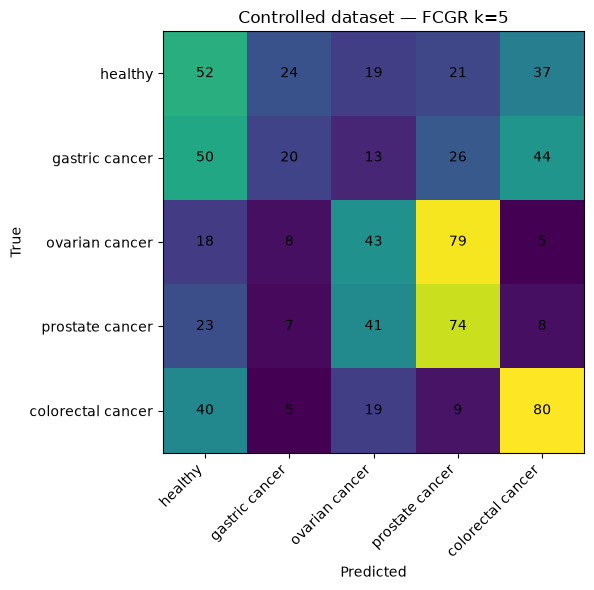

In [107]:
cm_fcgr = confusion_matrix(
    best_fcgr_metrics["y_true"],
    best_fcgr_metrics["y_pred"]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

im = ax.imshow(cm_fcgr)

ax.set_xticks(
    np.arange(len(CLASSES))
)

ax.set_yticks(
    np.arange(len(CLASSES))
)

ax.set_xticklabels(
    CLASSES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASSES
)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(
    "Controlled dataset — FCGR k=5"
)

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(
            j,
            i,
            cm_fcgr[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## PFCGR

In [108]:
test_id = str(
    controlled_index_df.iloc[0]["id"]
)

test_sequence = controlled_sequences[
    test_id
]

test_pfcgr = compute_pfcgr_reference(
    test_sequence,
    k=K
)

test_fcgr = normalize_fcgr_relative(
    compute_fcgr_counts(
        test_sequence,
        K
    )
)

print(
    "PFCGR shape:",
    test_pfcgr.shape
)

print(
    "Frequency channel equals FCGR:",
    np.allclose(
        test_pfcgr[0],
        test_fcgr
    )
)

print(
    "Maximum difference:",
    np.abs(
        test_pfcgr[0]
        - test_fcgr
    ).max()
)

PFCGR shape: (5, 32, 32)
Frequency channel equals FCGR: True
Maximum difference: 0.0


## Generazione della cache PFCGR sul dataset controllato

La baseline FCGR sul dataset controllato è stata resa deterministica
e viene ora congelata.

La PFCGR viene generata sugli stessi identici campioni utilizzati
dalla FCGR standard.

Ogni sequenza viene rappresentata da cinque canali:

1. frequenza dei k-mer;
2. posizione media;
3. deviazione standard delle posizioni;
4. skewness delle posizioni;
5. kurtosis delle posizioni.

Il primo canale è costruito con la stessa normalizzazione della FCGR
standard (`count / total valid k-mers`), in modo che il confronto
FCGR vs PFCGR differisca esclusivamente per l'aggiunta
dell'informazione posizionale.



In [109]:
CONTROLLED_PFCGR_DIR = (
    PROCESSED_DIR
    / "pfcgr_cache_controlled"
)

CONTROLLED_PFCGR_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CONTROLLED_PFCGR_PATH = (
    CONTROLLED_PFCGR_DIR
    / "pfcgr_k5.npy"
)

print(CONTROLLED_PFCGR_PATH)

..\data\processed\pfcgr_cache_controlled\pfcgr_k5.npy


In [110]:
N_PILOT = 100

pilot_pfcgr = []

for i in tqdm(
    range(N_PILOT),
    total=N_PILOT
):

    seq_id = str(
        controlled_index_df.iloc[i]["id"]
    )

    sequence = controlled_sequences[
        seq_id
    ]

    pfcgr = compute_pfcgr_reference(
        sequence,
        k=K
    )

    pilot_pfcgr.append(
        pfcgr
    )

pilot_pfcgr = np.stack(
    pilot_pfcgr,
    axis=0
)

print(
    "Shape:",
    pilot_pfcgr.shape
)

print(
    "dtype:",
    pilot_pfcgr.dtype
)

print(
    "finite:",
    np.isfinite(
        pilot_pfcgr
    ).all()
)

print(
    "min:",
    pilot_pfcgr.min()
)

print(
    "max:",
    pilot_pfcgr.max()
)

  0%|          | 0/100 [00:00<?, ?it/s]

Shape: (100, 5, 32, 32)
dtype: float32
finite: True
min: 0.0
max: 1.0


In [111]:
frequency_differences = []

for i in range(N_PILOT):

    pfcgr_frequency = (
        pilot_pfcgr[i, 0]
    )

    fcgr_standard = (
        controlled_fcgr_cache[i]
    )

    max_diff = np.abs(
        pfcgr_frequency
        - fcgr_standard
    ).max()

    frequency_differences.append(
        max_diff
    )

print(
    "Maximum difference over 100 sequences:",
    np.max(
        frequency_differences
    )
)

print(
    "All frequency channels equal FCGR:",
    np.allclose(
        pilot_pfcgr[:, 0],
        np.asarray(
            controlled_fcgr_cache[
                :N_PILOT
            ]
        )
    )
)

Maximum difference over 100 sequences: 0.0
All frequency channels equal FCGR: True


In [112]:
pilot_nonzero = []

for sample_idx in range(
    len(pilot_pfcgr)
):

    row = {}

    for channel_idx, channel_name in enumerate(
        CHANNEL_NAMES
    ):

        row[channel_name] = (
            np.count_nonzero(
                pilot_pfcgr[
                    sample_idx,
                    channel_idx
                ]
            )
        )

    pilot_nonzero.append(
        row
    )

pilot_nonzero_df = pd.DataFrame(
    pilot_nonzero
)

pilot_nonzero_df.describe()

,frequency,mean_position,std_position,skewness_position,kurtosis_position
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,126.460000,125.460000,13.990000,1.610000,0.450000
std,39.061831,39.061831,9.220635,1.984256,0.609272
min,15.000000,14.000000,1.000000,0.000000,0.000000
25%,97.750000,96.750000,6.000000,0.000000,0.000000
50%,130.000000,129.000000,12.000000,1.000000,0.000000
75%,158.500000,157.500000,20.000000,2.000000,1.000000
max,194.000000,193.000000,43.000000,9.000000,2.000000


In [113]:
if CONTROLLED_PFCGR_PATH.exists():

    print(
        "PFCGR cache already exists."
    )

    controlled_pfcgr_cache = np.load(
        CONTROLLED_PFCGR_PATH,
        mmap_mode="r"
    )

else:

    print(
        "Generating controlled PFCGR cache..."
    )

    controlled_pfcgr_cache = (
        np.lib.format.open_memmap(
            CONTROLLED_PFCGR_PATH,
            mode="w+",
            dtype=np.float32,
            shape=(
                len(controlled_index_df),
                5,
                SIZE,
                SIZE
            )
        )
    )

    for row_idx, row in tqdm(
        controlled_index_df.iterrows(),
        total=len(
            controlled_index_df
        )
    ):

        seq_id = str(
            row["id"]
        )

        sequence = controlled_sequences[
            seq_id
        ]

        pfcgr = compute_pfcgr_reference(
            sequence,
            k=K
        )

        controlled_pfcgr_cache[
            row_idx
        ] = pfcgr

    controlled_pfcgr_cache.flush()

    print(
        "PFCGR cache generated."
    )

PFCGR cache already exists.


In [114]:
controlled_pfcgr_cache = np.load(
    CONTROLLED_PFCGR_PATH,
    mmap_mode="r"
)

print(
    "Shape:",
    controlled_pfcgr_cache.shape
)

print(
    "dtype:",
    controlled_pfcgr_cache.dtype
)

print(
    "finite:",
    np.isfinite(
        controlled_pfcgr_cache
    ).all()
)

Shape: (8145, 5, 32, 32)
dtype: float32
finite: True


In [115]:
check_indices = [
    0,
    10,
    100,
    1000,
    len(
        controlled_pfcgr_cache
    ) - 1
]

for idx in check_indices:

    diff = np.abs(
        controlled_pfcgr_cache[
            idx,
            0
        ]
        - controlled_fcgr_cache[
            idx
        ]
    ).max()

    print(
        f"idx={idx:4d} | "
        f"frequency max diff={diff:.8f}"
    )

idx=   0 | frequency max diff=0.00000000
idx=  10 | frequency max diff=0.00000000
idx= 100 | frequency max diff=0.00000000
idx=1000 | frequency max diff=0.00000000
idx=8144 | frequency max diff=0.00000000


In [116]:
class ControlledPFCGRDataset(Dataset):

    def __init__(
        self,
        index_df,
        pfcgr_cache,
        class_to_idx
    ):

        self.index_df = (
            index_df
            .reset_index(drop=True)
            .copy()
        )

        self.pfcgr_cache = pfcgr_cache
        self.class_to_idx = class_to_idx

    def __len__(self):

        return len(
            self.index_df
        )

    def __getitem__(
        self,
        idx
    ):

        row = self.index_df.iloc[
            idx
        ]

        cache_idx = int(
            row["cache_index"]
        )

        x = np.asarray(
            self.pfcgr_cache[
                cache_idx
            ],
            dtype=np.float32
        ).copy()

        # Già [5, 32, 32]
        x = torch.from_numpy(
            x
        )

        y = self.class_to_idx[
            row["disease_clean"]
        ]

        y = torch.tensor(
            y,
            dtype=torch.long
        )

        return x, y

In [117]:
train_dataset_pfcgr = (
    ControlledPFCGRDataset(
        train_index_controlled,
        controlled_pfcgr_cache,
        CLASS_TO_IDX
    )
)

val_dataset_pfcgr = (
    ControlledPFCGRDataset(
        val_index_controlled,
        controlled_pfcgr_cache,
        CLASS_TO_IDX
    )
)

print(
    "Train:",
    len(train_dataset_pfcgr)
)

print(
    "Validation:",
    len(val_dataset_pfcgr)
)

Train: 7380
Validation: 765


In [118]:
x_pfcgr_test, y_pfcgr_test = (
    train_dataset_pfcgr[0]
)

print(
    "X shape:",
    x_pfcgr_test.shape
)

print(
    "X dtype:",
    x_pfcgr_test.dtype
)

print(
    "Label:",
    y_pfcgr_test.item()
)

print(
    "Disease:",
    IDX_TO_CLASS[
        y_pfcgr_test.item()
    ]
)

X shape: torch.Size([5, 32, 32])
X dtype: torch.float32
Label: 0
Disease: healthy


In [119]:
class MulticlassPFCGRCNN(nn.Module):

    def __init__(
        self,
        num_classes=5
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                5,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(
        self,
        x
    ):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [120]:
# ======================================================
# RESET ESPERIMENTO PFCGR
# ======================================================

set_reproducibility(SEED)

# DataLoader deterministico
pfcgr_train_generator = (
    torch.Generator()
)

pfcgr_train_generator.manual_seed(
    SEED
)

train_loader_pfcgr = DataLoader(
    train_dataset_pfcgr,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=pfcgr_train_generator
)

val_loader_pfcgr = DataLoader(
    val_dataset_pfcgr,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

# Modello nuovo
model_pfcgr = MulticlassPFCGRCNN(
    num_classes=len(CLASSES)
).to(DEVICE)

criterion_pfcgr = (
    nn.CrossEntropyLoss()
)

optimizer_pfcgr = (
    torch.optim.AdamW(
        model_pfcgr.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )
)

print(
    "PFCGR experiment reset complete."
)

print(
    "Parameters:",
    sum(
        p.numel()
        for p
        in model_pfcgr.parameters()
    )
)

PFCGR experiment reset complete.
Parameters: 102853


In [121]:
model_pfcgr.eval()

with torch.no_grad():

    test_batch_pfcgr = torch.stack([
        train_dataset_pfcgr[i][0]
        for i in range(8)
    ])

    test_logits_pfcgr = (
        model_pfcgr(
            test_batch_pfcgr.to(
                DEVICE
            )
        )
    )

print(
    "Logits shape:",
    test_logits_pfcgr.shape
)

model_pfcgr.train()

Logits shape: torch.Size([8, 5])


MulticlassPFCGRCNN(
  (features): Sequential(
    (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4

In [122]:
PFCGR_CHECKPOINT_PATH = (
    CONTROLLED_RESULTS_DIR
    / "pfcgr_k5_cnn_best.pt"
)

print(
    PFCGR_CHECKPOINT_PATH
)

..\results\multiclass_controlled\pfcgr_k5_cnn_best.pt


In [123]:
EPOCHS_PFCGR = 8

best_val_f1_pfcgr = -1.0
history_pfcgr = []

for epoch in range(
    1,
    EPOCHS_PFCGR + 1
):

    train_loss, train_f1 = (
        train_one_epoch_multiclass(
            model_pfcgr,
            train_loader_pfcgr,
            optimizer_pfcgr,
            criterion_pfcgr,
            DEVICE
        )
    )

    val_metrics = (
        evaluate_multiclass(
            model_pfcgr,
            val_loader_pfcgr,
            criterion_pfcgr,
            DEVICE
        )
    )

    history_pfcgr.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_macro_f1": train_f1,
        "val_loss": val_metrics[
            "loss"
        ],
        "val_macro_f1": val_metrics[
            "macro_f1"
        ],
        "val_bal_acc": val_metrics[
            "balanced_accuracy"
        ]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_f1={train_f1:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_f1={val_metrics['macro_f1']:.4f} | "
        f"val_bal={val_metrics['balanced_accuracy']:.4f}"
    )

    if (
        val_metrics["macro_f1"]
        > best_val_f1_pfcgr
    ):

        best_val_f1_pfcgr = (
            val_metrics[
                "macro_f1"
            ]
        )

        torch.save(
            model_pfcgr.state_dict(),
            PFCGR_CHECKPOINT_PATH
        )

        print(
            "  -> best PFCGR checkpoint saved"
        )

Epoch 01 | train_loss=1.6007 | train_f1=0.1825 | val_loss=1.6086 | val_f1=0.0924 | val_bal=0.2065
  -> best PFCGR checkpoint saved
Epoch 02 | train_loss=1.5764 | train_f1=0.2732 | val_loss=1.5641 | val_f1=0.2761 | val_bal=0.3072
  -> best PFCGR checkpoint saved
Epoch 03 | train_loss=1.5451 | train_f1=0.2894 | val_loss=1.5230 | val_f1=0.3125 | val_bal=0.3320
  -> best PFCGR checkpoint saved
Epoch 04 | train_loss=1.5134 | train_f1=0.3007 | val_loss=1.4885 | val_f1=0.2838 | val_bal=0.3216
Epoch 05 | train_loss=1.4836 | train_f1=0.3024 | val_loss=1.4595 | val_f1=0.2821 | val_bal=0.3307
Epoch 06 | train_loss=1.4575 | train_f1=0.3176 | val_loss=1.4482 | val_f1=0.2809 | val_bal=0.3307
Epoch 07 | train_loss=1.4384 | train_f1=0.3106 | val_loss=1.4194 | val_f1=0.3040 | val_bal=0.3320
Epoch 08 | train_loss=1.4238 | train_f1=0.3137 | val_loss=1.4131 | val_f1=0.3315 | val_bal=0.3569
  -> best PFCGR checkpoint saved


In [124]:
history_pfcgr_df = (
    pd.DataFrame(
        history_pfcgr
    )
)

history_pfcgr_df

,epoch,train_loss,train_macro_f1,val_loss,val_macro_f1,val_bal_acc
0,1,1.600692,0.182466,1.608575,0.092436,0.206536
1,2,1.576448,0.273174,1.564075,0.276115,0.307190
2,3,1.545104,0.289436,1.523025,0.312458,0.332026
3,4,1.513395,0.300668,1.488516,0.283775,0.321569
4,5,1.483553,0.302388,1.459543,0.282091,0.330719
5,6,1.457496,0.317600,1.448186,0.280891,0.330719
6,7,1.438350,0.310572,1.419393,0.303960,0.332026
7,8,1.423795,0.313683,1.413062,0.331458,0.356863


In [125]:
print(
    f"Best controlled PFCGR "
    f"validation Macro F1: "
    f"{best_val_f1_pfcgr:.4f}"
)

Best controlled PFCGR validation Macro F1: 0.3315


In [126]:
model_pfcgr.load_state_dict(
    torch.load(
        PFCGR_CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=True
    )
)

best_pfcgr_metrics = (
    evaluate_multiclass(
        model_pfcgr,
        val_loader_pfcgr,
        criterion_pfcgr,
        DEVICE
    )
)

print(
    f"PFCGR Macro F1: "
    f"{best_pfcgr_metrics['macro_f1']:.4f}"
)

print(
    f"PFCGR Balanced Accuracy: "
    f"{best_pfcgr_metrics['balanced_accuracy']:.4f}"
)

print(
    f"PFCGR Accuracy: "
    f"{best_pfcgr_metrics['accuracy']:.4f}"
)

PFCGR Macro F1: 0.3315
PFCGR Balanced Accuracy: 0.3569
PFCGR Accuracy: 0.3569


conronto

In [127]:
comparison_fcgr_pfcgr = pd.DataFrame([
    {
        "representation": "FCGR",
        "channels": 1,
        "macro_f1": best_fcgr_metrics[
            "macro_f1"
        ],
        "balanced_accuracy":
            best_fcgr_metrics[
                "balanced_accuracy"
            ],
        "accuracy":
            best_fcgr_metrics[
                "accuracy"
            ]
    },
    {
        "representation": "PFCGR",
        "channels": 5,
        "macro_f1": best_pfcgr_metrics[
            "macro_f1"
        ],
        "balanced_accuracy":
            best_pfcgr_metrics[
                "balanced_accuracy"
            ],
        "accuracy":
            best_pfcgr_metrics[
                "accuracy"
            ]
    }
])

comparison_fcgr_pfcgr

,representation,channels,macro_f1,balanced_accuracy,accuracy
0,FCGR,1,0.338121,0.351634,0.351634
1,PFCGR,5,0.331458,0.356863,0.356863


In [128]:
delta_f1 = (
    best_pfcgr_metrics[
        "macro_f1"
    ]
    -
    best_fcgr_metrics[
        "macro_f1"
    ]
)

print(
    f"FCGR Macro F1:  "
    f"{best_fcgr_metrics['macro_f1']:.4f}"
)

print(
    f"PFCGR Macro F1: "
    f"{best_pfcgr_metrics['macro_f1']:.4f}"
)

print(
    f"Delta PFCGR - FCGR: "
    f"{delta_f1:+.4f}"
)

FCGR Macro F1:  0.3381
PFCGR Macro F1: 0.3315
Delta PFCGR - FCGR: -0.0067


3 seed identici per fcgr e pfcgr

In [129]:
EXPERIMENT_SEEDS = [42, 123, 2026]

In [130]:
MAX_EPOCHS = 50
PATIENCE = 10
MIN_DELTA = 1e-4

In [131]:
# funzione per un singolo esperimento

import copy


def run_multiclass_experiment(
    model_class,
    train_dataset,
    val_dataset,
    seed,
    max_epochs=50,
    patience=10,
    min_delta=1e-4,
    lr=1e-4,
    weight_decay=1e-4
):

    # ==================================================
    # RIPRODUCIBILITÀ
    # ==================================================

    set_reproducibility(seed)

    generator = torch.Generator()
    generator.manual_seed(seed)

    # ==================================================
    # DATALOADER
    # ==================================================

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    # ==================================================
    # MODELLO
    # ==================================================

    model = model_class(
        num_classes=len(CLASSES)
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # ==================================================
    # TRACKING
    # ==================================================

    best_f1 = -1.0
    best_bal_acc = -1.0
    best_accuracy = -1.0

    best_epoch = None
    best_state = None

    epochs_without_improvement = 0

    history = []

    # ==================================================
    # TRAINING
    # ==================================================

    for epoch in range(
        1,
        max_epochs + 1
    ):

        train_loss, train_f1 = (
            train_one_epoch_multiclass(
                model,
                train_loader,
                optimizer,
                criterion,
                DEVICE
            )
        )

        val_metrics = (
            evaluate_multiclass(
                model,
                val_loader,
                criterion,
                DEVICE
            )
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_macro_f1": train_f1,
            "val_loss": val_metrics["loss"],
            "val_macro_f1":
                val_metrics["macro_f1"],
            "val_balanced_accuracy":
                val_metrics[
                    "balanced_accuracy"
                ],
            "val_accuracy":
                val_metrics["accuracy"]
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_f1={train_f1:.4f} | "
            f"val_f1="
            f"{val_metrics['macro_f1']:.4f} | "
            f"val_bal="
            f"{val_metrics['balanced_accuracy']:.4f}"
        )

        # ==================================================
        # MIGLIORAMENTO
        # ==================================================

        if (
            val_metrics["macro_f1"]
            > best_f1 + min_delta
        ):

            best_f1 = (
                val_metrics["macro_f1"]
            )

            best_bal_acc = (
                val_metrics[
                    "balanced_accuracy"
                ]
            )

            best_accuracy = (
                val_metrics["accuracy"]
            )

            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

            print(
                "  -> new best checkpoint"
            )

        else:

            epochs_without_improvement += 1

        # ==================================================
        # EARLY STOPPING
        # ==================================================

        if (
            epochs_without_improvement
            >= patience
        ):

            print(
                f"Early stopping at epoch "
                f"{epoch}"
            )

            break

    # ==================================================
    # RIPRISTINA BEST MODEL
    # ==================================================

    model.load_state_dict(
        best_state
    )

    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "epochs_run": epoch,
        "macro_f1": best_f1,
        "balanced_accuracy":
            best_bal_acc,
        "accuracy":
            best_accuracy,
        "history":
            history
    }

In [132]:
multi_seed_results_long = []

for seed in EXPERIMENT_SEEDS:

    print(
        f"\n{'='*60}"
    )
    print(
        f"SEED {seed} | FCGR"
    )
    print(
        f"{'='*60}"
    )

    fcgr_result = (
        run_multiclass_experiment(
            MulticlassFCGRCNN,
            train_dataset_controlled,
            val_dataset_controlled,
            seed=seed,
            max_epochs=50,
            patience=10
        )
    )

    multi_seed_results_long.append({
        "representation": "FCGR",
        "seed": seed,
        "best_epoch":
            fcgr_result["best_epoch"],
        "epochs_run":
            fcgr_result["epochs_run"],
        "macro_f1":
            fcgr_result["macro_f1"],
        "balanced_accuracy":
            fcgr_result[
                "balanced_accuracy"
            ],
        "accuracy":
            fcgr_result["accuracy"]
    })

    print(
        f"\n{'='*60}"
    )
    print(
        f"SEED {seed} | PFCGR"
    )
    print(
        f"{'='*60}"
    )

    pfcgr_result = (
        run_multiclass_experiment(
            MulticlassPFCGRCNN,
            train_dataset_pfcgr,
            val_dataset_pfcgr,
            seed=seed,
            max_epochs=50,
            patience=10
        )
    )

    multi_seed_results_long.append({
        "representation": "PFCGR",
        "seed": seed,
        "best_epoch":
            pfcgr_result["best_epoch"],
        "epochs_run":
            pfcgr_result["epochs_run"],
        "macro_f1":
            pfcgr_result["macro_f1"],
        "balanced_accuracy":
            pfcgr_result[
                "balanced_accuracy"
            ],
        "accuracy":
            pfcgr_result["accuracy"]
    })


SEED 42 | FCGR
Epoch 01 | train_f1=0.2311 | val_f1=0.0667 | val_bal=0.2000
  -> new best checkpoint
Epoch 02 | train_f1=0.3019 | val_f1=0.1828 | val_bal=0.3190
  -> new best checkpoint
Epoch 03 | train_f1=0.3127 | val_f1=0.1687 | val_bal=0.2889
Epoch 04 | train_f1=0.3163 | val_f1=0.2434 | val_bal=0.3255
  -> new best checkpoint
Epoch 05 | train_f1=0.3145 | val_f1=0.2721 | val_bal=0.3490
  -> new best checkpoint
Epoch 06 | train_f1=0.3228 | val_f1=0.3381 | val_bal=0.3516
  -> new best checkpoint
Epoch 07 | train_f1=0.3291 | val_f1=0.2606 | val_bal=0.3503
Epoch 08 | train_f1=0.3345 | val_f1=0.2927 | val_bal=0.3451
Epoch 09 | train_f1=0.3405 | val_f1=0.2467 | val_bal=0.3033
Epoch 10 | train_f1=0.3371 | val_f1=0.3005 | val_bal=0.3399
Epoch 11 | train_f1=0.3483 | val_f1=0.2700 | val_bal=0.3281
Epoch 12 | train_f1=0.3394 | val_f1=0.3439 | val_bal=0.3660
  -> new best checkpoint
Epoch 13 | train_f1=0.3542 | val_f1=0.3003 | val_bal=0.3477
Epoch 14 | train_f1=0.3543 | val_f1=0.2468 | val_bal=0

In [133]:
multi_seed_long_df = pd.DataFrame(
    multi_seed_results_long
)

multi_seed_long_df

,representation,seed,best_epoch,epochs_run,macro_f1,balanced_accuracy,accuracy
0,FCGR,42,18,28,0.352129,0.369935,0.369935
1,PFCGR,42,19,29,0.346346,0.363399,0.363399
2,FCGR,123,7,17,0.345262,0.367320,0.367320
3,PFCGR,123,18,28,0.356307,0.383007,0.383007
4,FCGR,2026,9,19,0.343795,0.379085,0.379085
5,PFCGR,2026,24,34,0.350255,0.362092,0.362092


In [134]:
summary_long = (
    multi_seed_long_df
    .groupby("representation")
    .agg(
        macro_f1_mean=(
            "macro_f1",
            "mean"
        ),
        macro_f1_std=(
            "macro_f1",
            "std"
        ),
        balanced_acc_mean=(
            "balanced_accuracy",
            "mean"
        ),
        balanced_acc_std=(
            "balanced_accuracy",
            "std"
        ),
        mean_best_epoch=(
            "best_epoch",
            "mean"
        )
    )
)

summary_long

,macro_f1_mean,macro_f1_std,balanced_acc_mean,balanced_acc_std,mean_best_epoch
representation,,,,,
FCGR,0.347062,0.004449,0.372113,0.006178,11.333333
PFCGR,0.350969,0.005019,0.369499,0.011716,20.333333


In [135]:
summary_multi_seed = (
    multi_seed_long_df
    .groupby(
        "representation"
    )
    .agg(
        macro_f1_mean=(
            "macro_f1",
            "mean"
        ),
        macro_f1_std=(
            "macro_f1",
            "std"
        ),
        balanced_acc_mean=(
            "balanced_accuracy",
            "mean"
        ),
        balanced_acc_std=(
            "balanced_accuracy",
            "std"
        )
    )
)

summary_multi_seed

,macro_f1_mean,macro_f1_std,balanced_acc_mean,balanced_acc_std
representation,,,,
FCGR,0.347062,0.004449,0.372113,0.006178
PFCGR,0.350969,0.005019,0.369499,0.011716


In [136]:
for representation in [
    "FCGR",
    "PFCGR"
]:

    subset = multi_seed_long_df[
        multi_seed_long_df[
            "representation"
        ] == representation
    ]

    print(
        f"{representation}: "
        f"Macro F1 = "
        f"{subset['macro_f1'].mean():.4f} "
        f"± "
        f"{subset['macro_f1'].std():.4f}"
    )

FCGR: Macro F1 = 0.3471 ± 0.0044
PFCGR: Macro F1 = 0.3510 ± 0.0050


esperimento per capire prolema

In [137]:
tiny_indices = []

for disease in CLASSES:

    class_indices = (
        train_index_controlled[
            train_index_controlled["disease_clean"]
            == disease
        ]
        .sample(
            n=50,
            random_state=42
        )
        .index
        .tolist()
    )

    tiny_indices.extend(
        class_indices
    )

tiny_subset = torch.utils.data.Subset(
    train_dataset_controlled,
    tiny_indices
)

print(
    "Tiny dataset:",
    len(tiny_subset)
)

Tiny dataset: 250


In [138]:
set_reproducibility(42)

tiny_generator = torch.Generator()
tiny_generator.manual_seed(42)

tiny_loader = DataLoader(
    tiny_subset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    generator=tiny_generator
)

tiny_model = MulticlassFCGRCNN(
    num_classes=5
).to(DEVICE)

tiny_criterion = nn.CrossEntropyLoss()

tiny_optimizer = torch.optim.AdamW(
    tiny_model.parameters(),
    lr=1e-3,
    weight_decay=0
)

In [139]:
for epoch in range(
    1,
    101
):

    train_loss, train_f1 = (
        train_one_epoch_multiclass(
            tiny_model,
            tiny_loader,
            tiny_optimizer,
            tiny_criterion,
            DEVICE
        )
    )

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        print(
            f"Epoch {epoch:03d} | "
            f"loss={train_loss:.4f} | "
            f"train_f1={train_f1:.4f}"
        )

Epoch 001 | loss=1.6084 | train_f1=0.1562
Epoch 010 | loss=1.2797 | train_f1=0.3571
Epoch 020 | loss=0.9596 | train_f1=0.6458
Epoch 030 | loss=0.4809 | train_f1=0.8725
Epoch 040 | loss=0.2696 | train_f1=0.9114
Epoch 050 | loss=0.1722 | train_f1=0.9561
Epoch 060 | loss=0.1857 | train_f1=0.9564
Epoch 070 | loss=0.2074 | train_f1=0.9320
Epoch 080 | loss=0.0470 | train_f1=0.9960
Epoch 090 | loss=0.0837 | train_f1=0.9760
Epoch 100 | loss=0.0688 | train_f1=0.9760


Nuova cnn per continuare a esplorare problemi

In [140]:
class MulticlassFCGRSpatialCNN(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1, 32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        # Input 32x32
        # dopo due MaxPool -> 8x8
        # NON facciamo AdaptiveAvgPool(1,1)

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 8 * 8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [141]:
spatial_model_test = MulticlassFCGRSpatialCNN(
    num_classes=len(CLASSES)
)

print(
    "Spatial CNN parameters:",
    sum(
        p.numel()
        for p in spatial_model_test.parameters()
    )
)

baseline_model_test = MulticlassFCGRCNN(
    num_classes=len(CLASSES)
)

print(
    "Baseline CNN parameters:",
    sum(
        p.numel()
        for p in baseline_model_test.parameters()
    )
)

Spatial CNN parameters: 1142469
Baseline CNN parameters: 101701


In [142]:
SPATIAL_SEEDS = [
    42,
    123,
    2026
]

spatial_results = []

for seed in SPATIAL_SEEDS:

    print(
        f"\n{'='*60}"
    )
    print(
        f"SEED {seed} | FCGR SPATIAL CNN"
    )
    print(
        f"{'='*60}"
    )

    result = run_multiclass_experiment(
        MulticlassFCGRSpatialCNN,
        train_dataset_controlled,
        val_dataset_controlled,
        seed=seed,
        max_epochs=50,
        patience=10
    )

    spatial_results.append({
        "representation": "FCGR Spatial",
        "seed": seed,
        "best_epoch":
            result["best_epoch"],
        "epochs_run":
            result["epochs_run"],
        "macro_f1":
            result["macro_f1"],
        "balanced_accuracy":
            result["balanced_accuracy"],
        "accuracy":
            result["accuracy"]
    })


SEED 42 | FCGR SPATIAL CNN
Epoch 01 | train_f1=0.3241 | val_f1=0.0667 | val_bal=0.2000
  -> new best checkpoint
Epoch 02 | train_f1=0.3779 | val_f1=0.0667 | val_bal=0.2000
Epoch 03 | train_f1=0.4006 | val_f1=0.1215 | val_bal=0.2144
  -> new best checkpoint
Epoch 04 | train_f1=0.4436 | val_f1=0.3450 | val_bal=0.3752
  -> new best checkpoint
Epoch 05 | train_f1=0.4586 | val_f1=0.3373 | val_bal=0.3869
Epoch 06 | train_f1=0.4875 | val_f1=0.3695 | val_bal=0.3856
  -> new best checkpoint
Epoch 07 | train_f1=0.5210 | val_f1=0.3235 | val_bal=0.3660
Epoch 08 | train_f1=0.5672 | val_f1=0.3339 | val_bal=0.3582
Epoch 09 | train_f1=0.5802 | val_f1=0.2728 | val_bal=0.3163
Epoch 10 | train_f1=0.6201 | val_f1=0.3403 | val_bal=0.3817
Epoch 11 | train_f1=0.6420 | val_f1=0.3195 | val_bal=0.3752
Epoch 12 | train_f1=0.6763 | val_f1=0.3192 | val_bal=0.3281
Epoch 13 | train_f1=0.7073 | val_f1=0.3156 | val_bal=0.3255
Epoch 14 | train_f1=0.7263 | val_f1=0.3273 | val_bal=0.3516
Epoch 15 | train_f1=0.7581 | val

In [143]:
spatial_results_df = pd.DataFrame(
    spatial_results
)

spatial_results_df

,representation,seed,best_epoch,epochs_run,macro_f1,balanced_accuracy,accuracy
0,FCGR Spatial,42,6,16,0.369532,0.385621,0.385621
1,FCGR Spatial,123,10,20,0.357515,0.366013,0.366013
2,FCGR Spatial,2026,7,17,0.353794,0.362092,0.362092


In [144]:
print(
    "Spatial FCGR Macro F1:",
    f"{spatial_results_df['macro_f1'].mean():.4f}",
    "±",
    f"{spatial_results_df['macro_f1'].std():.4f}"
)

Spatial FCGR Macro F1: 0.3603 ± 0.0082


In [145]:
class MulticlassFCGRSpatialMediumCNN(nn.Module):

    def __init__(
        self,
        num_classes=5
    ):

        super().__init__()

        self.features = nn.Sequential(

            # 32x32
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # 32x32 -> 16x16
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 16x16 -> 8x8
            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 8x8 -> 4x4
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            # 64 feature maps × 4 × 4
            nn.Linear(
                64 * 4 * 4,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [146]:
medium_model_test = (
    MulticlassFCGRSpatialMediumCNN(
        num_classes=len(CLASSES)
    )
)

print(
    "Spatial Medium parameters:",
    sum(
        p.numel()
        for p in medium_model_test.parameters()
    )
)

baseline_model_test = (
    MulticlassFCGRCNN(
        num_classes=len(CLASSES)
    )
)

print(
    "GAP Baseline parameters:",
    sum(
        p.numel()
        for p in baseline_model_test.parameters()
    )
)

Spatial Medium parameters: 121989
GAP Baseline parameters: 101701


In [147]:
MEDIUM_SEEDS = [
    42,
    123,
    2026
]

medium_results = []

for seed in MEDIUM_SEEDS:

    print(
        f"\n{'='*60}"
    )

    print(
        f"SEED {seed} | "
        f"FCGR SPATIAL MEDIUM"
    )

    print(
        f"{'='*60}"
    )

    result = (
        run_multiclass_experiment(

            MulticlassFCGRSpatialMediumCNN,

            train_dataset_controlled,
            val_dataset_controlled,

            seed=seed,

            max_epochs=50,
            patience=10
        )
    )

    medium_results.append({

        "model":
            "Spatial Medium",

        "seed":
            seed,

        "best_epoch":
            result["best_epoch"],

        "epochs_run":
            result["epochs_run"],

        "macro_f1":
            result["macro_f1"],

        "balanced_accuracy":
            result[
                "balanced_accuracy"
            ],

        "accuracy":
            result["accuracy"]
    })


SEED 42 | FCGR SPATIAL MEDIUM
Epoch 01 | train_f1=0.3065 | val_f1=0.0797 | val_bal=0.2065
  -> new best checkpoint
Epoch 02 | train_f1=0.3341 | val_f1=0.0845 | val_bal=0.2092
  -> new best checkpoint
Epoch 03 | train_f1=0.3572 | val_f1=0.2162 | val_bal=0.2889
  -> new best checkpoint
Epoch 04 | train_f1=0.3657 | val_f1=0.3438 | val_bal=0.3569
  -> new best checkpoint
Epoch 05 | train_f1=0.3724 | val_f1=0.3183 | val_bal=0.3373
Epoch 06 | train_f1=0.3912 | val_f1=0.3172 | val_bal=0.3529
Epoch 07 | train_f1=0.4032 | val_f1=0.2823 | val_bal=0.3556
Epoch 08 | train_f1=0.4079 | val_f1=0.3184 | val_bal=0.3791
Epoch 09 | train_f1=0.4262 | val_f1=0.3275 | val_bal=0.3621
Epoch 10 | train_f1=0.4224 | val_f1=0.2752 | val_bal=0.3412
Epoch 11 | train_f1=0.4339 | val_f1=0.3063 | val_bal=0.3542
Epoch 12 | train_f1=0.4481 | val_f1=0.3191 | val_bal=0.3699
Epoch 13 | train_f1=0.4537 | val_f1=0.3287 | val_bal=0.3595
Epoch 14 | train_f1=0.4724 | val_f1=0.3521 | val_bal=0.3647
  -> new best checkpoint
Epoc

In [148]:
medium_results_df = pd.DataFrame(
    medium_results
)

medium_results_df

,model,seed,best_epoch,epochs_run,macro_f1,balanced_accuracy,accuracy
0,Spatial Medium,42,21,31,0.361373,0.369935,0.369935
1,Spatial Medium,123,18,28,0.366974,0.376471,0.376471
2,Spatial Medium,2026,22,32,0.361237,0.367320,0.367320


In [149]:
print(
    "Spatial Medium Macro F1:",
    f"{medium_results_df['macro_f1'].mean():.4f}",
    "±",
    f"{medium_results_df['macro_f1'].std():.4f}"
)

Spatial Medium Macro F1: 0.3632 ± 0.0033


altro test per capire s eprobblema è k

In [150]:
def build_controlled_fcgr_cache(
    k,
    controlled_index_df,
    controlled_sequences,
    output_dir
):

    size = 2 ** k

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    cache_path = (
        output_dir
        / f"fcgr_k{k}.npy"
    )

    if cache_path.exists():

        print(
            f"Cache k={k} già presente."
        )

        return np.load(
            cache_path,
            mmap_mode="r"
        )

    print(
        f"Genero cache FCGR k={k}..."
    )

    cache = np.lib.format.open_memmap(
        cache_path,
        mode="w+",
        dtype=np.float32,
        shape=(
            len(controlled_index_df),
            size,
            size
        )
    )

    for idx, row in tqdm(
        controlled_index_df.iterrows(),
        total=len(controlled_index_df)
    ):

        seq_id = str(
            row["id"]
        )

        sequence = controlled_sequences[
            seq_id
        ]

        fcgr_counts = compute_fcgr_counts(
            sequence,
            k
        )

        fcgr_norm = (
            normalize_fcgr_relative(
                fcgr_counts
            )
        )

        cache[idx] = fcgr_norm

    cache.flush()

    return np.load(
        cache_path,
        mmap_mode="r"
    )

In [151]:
FCGR_MULTI_K_DIR = (
    PROCESSED_DIR
    / "fcgr_cache_controlled_multik"
)

fcgr_cache_k3 = (
    build_controlled_fcgr_cache(
        3,
        controlled_index_df,
        controlled_sequences,
        FCGR_MULTI_K_DIR
    )
)

fcgr_cache_k4 = (
    build_controlled_fcgr_cache(
        4,
        controlled_index_df,
        controlled_sequences,
        FCGR_MULTI_K_DIR
    )
)

Cache k=3 già presente.
Cache k=4 già presente.


In [152]:
print(
    "k=3:",
    fcgr_cache_k3.shape
)

print(
    "k=4:",
    fcgr_cache_k4.shape
)

print(
    "k=5:",
    controlled_fcgr_cache.shape
)

k=3: (8145, 8, 8)
k=4: (8145, 16, 16)
k=5: (8145, 32, 32)


In [153]:
def compute_cache_sparsity(
    cache,
    n_samples=500
):

    values = []

    n = min(
        n_samples,
        len(cache)
    )

    for i in range(n):

        matrix = cache[i]

        sparsity = (
            1.0
            -
            np.count_nonzero(matrix)
            / matrix.size
        )

        values.append(
            sparsity
        )

    return np.array(values)

In [154]:
for k, cache in [
    (3, fcgr_cache_k3),
    (4, fcgr_cache_k4),
    (5, controlled_fcgr_cache)
]:

    sparsity = (
        compute_cache_sparsity(
            cache
        )
    )

    print(
        f"k={k} | "
        f"mean sparsity="
        f"{sparsity.mean():.4f} | "
        f"median="
        f"{np.median(sparsity):.4f}"
    )

k=3 | mean sparsity=0.1948 | median=0.1719
k=4 | mean sparsity=0.5921 | median=0.5859
k=5 | mean sparsity=0.8651 | median=0.8643


In [155]:
for k, cache in [
    (3, fcgr_cache_k3),
    (4, fcgr_cache_k4),
    (5, controlled_fcgr_cache)
]:

    sparsity = (
        compute_cache_sparsity(
            cache
        )
    )

    print(
        f"k={k} | "
        f"mean sparsity="
        f"{sparsity.mean():.4f} | "
        f"median="
        f"{np.median(sparsity):.4f}"
    )

k=3 | mean sparsity=0.1948 | median=0.1719
k=4 | mean sparsity=0.5921 | median=0.5859
k=5 | mean sparsity=0.8651 | median=0.8643


In [156]:
train_dataset_k3 = (
    ControlledFCGRDataset(
        train_index_controlled,
        fcgr_cache_k3,
        CLASS_TO_IDX
    )
)

val_dataset_k3 = (
    ControlledFCGRDataset(
        val_index_controlled,
        fcgr_cache_k3,
        CLASS_TO_IDX
    )
)

train_dataset_k4 = (
    ControlledFCGRDataset(
        train_index_controlled,
        fcgr_cache_k4,
        CLASS_TO_IDX
    )
)

val_dataset_k4 = (
    ControlledFCGRDataset(
        val_index_controlled,
        fcgr_cache_k4,
        CLASS_TO_IDX
    )
)

train_dataset_k5 = (
    train_dataset_controlled
)

val_dataset_k5 = (
    val_dataset_controlled
)

In [165]:
import torch.nn.functional as F

In [166]:
class MulticlassFCGRSpatialAdaptiveCNN(nn.Module):

    def __init__(
        self,
        num_classes=5
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64 * 4 * 4,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        # ==================================================
        # POOLING DETERMINISTICO
        # ==================================================
        #
        # k=3 -> 8x8  -> pooling 2x2 -> 4x4
        # k=4 -> 16x16 -> pooling 4x4 -> 4x4
        # k=5 -> 32x32 -> pooling 8x8 -> 4x4
        #
        # Usiamo AvgPool2d standard, NON AdaptiveAvgPool2d.

        spatial_size = x.shape[-1]

        pool_size = (
            spatial_size // 4
        )

        x = F.avg_pool2d(
            x,
            kernel_size=pool_size,
            stride=pool_size
        )

        x = self.classifier(x)

        return x

In [167]:
model_test = (
    MulticlassFCGRSpatialAdaptiveCNN(
        num_classes=5
    )
)

for dataset, k in [
    (train_dataset_k3, 3),
    (train_dataset_k4, 4),
    (train_dataset_k5, 5)
]:

    x, y = dataset[0]

    out = model_test(
        x.unsqueeze(0)
    )

    print(
        f"k={k} | "
        f"input={x.shape} | "
        f"output={out.shape}"
    )

k=3 | input=torch.Size([1, 8, 8]) | output=torch.Size([1, 5])
k=4 | input=torch.Size([1, 16, 16]) | output=torch.Size([1, 5])
k=5 | input=torch.Size([1, 32, 32]) | output=torch.Size([1, 5])


In [168]:
K_DATASETS = {
    3: (
        train_dataset_k3,
        val_dataset_k3
    ),

    4: (
        train_dataset_k4,
        val_dataset_k4
    ),

    5: (
        train_dataset_k5,
        val_dataset_k5
    )
}

SEEDS = [
    42,
    123,
    2026
]

In [169]:
k_results = []

for k, (
    train_ds,
    val_ds
) in K_DATASETS.items():

    for seed in SEEDS:

        print(
            f"\n"
            f"{'='*60}"
        )

        print(
            f"k={k} | "
            f"seed={seed}"
        )

        print(
            f"{'='*60}"
        )

        result = (
            run_multiclass_experiment(

                MulticlassFCGRSpatialAdaptiveCNN,

                train_ds,
                val_ds,

                seed=seed,

                max_epochs=50,
                patience=10
            )
        )

        k_results.append({
            "k": k,
            "seed": seed,

            "best_epoch":
                result[
                    "best_epoch"
                ],

            "macro_f1":
                result[
                    "macro_f1"
                ],

            "balanced_accuracy":
                result[
                    "balanced_accuracy"
                ],

            "accuracy":
                result[
                    "accuracy"
                ]
        })


k=3 | seed=42
Epoch 01 | train_f1=0.3000 | val_f1=0.0667 | val_bal=0.2000
  -> new best checkpoint
Epoch 02 | train_f1=0.3308 | val_f1=0.1502 | val_bal=0.2575
  -> new best checkpoint
Epoch 03 | train_f1=0.3549 | val_f1=0.2750 | val_bal=0.3582
  -> new best checkpoint
Epoch 04 | train_f1=0.3642 | val_f1=0.3447 | val_bal=0.3765
  -> new best checkpoint
Epoch 05 | train_f1=0.3693 | val_f1=0.3552 | val_bal=0.3817
  -> new best checkpoint
Epoch 06 | train_f1=0.3823 | val_f1=0.3386 | val_bal=0.3739
Epoch 07 | train_f1=0.3923 | val_f1=0.3447 | val_bal=0.3856
Epoch 08 | train_f1=0.3954 | val_f1=0.3587 | val_bal=0.3908
  -> new best checkpoint
Epoch 09 | train_f1=0.4051 | val_f1=0.3643 | val_bal=0.3922
  -> new best checkpoint
Epoch 10 | train_f1=0.4001 | val_f1=0.3729 | val_bal=0.3922
  -> new best checkpoint
Epoch 11 | train_f1=0.4100 | val_f1=0.3486 | val_bal=0.3817
Epoch 12 | train_f1=0.4155 | val_f1=0.3507 | val_bal=0.3869
Epoch 13 | train_f1=0.4190 | val_f1=0.3442 | val_bal=0.3948
Epoch

In [170]:
k_results_df = pd.DataFrame(
    k_results
)

k_results_df

,k,seed,best_epoch,macro_f1,balanced_accuracy,accuracy
0,3,42,32,0.401378,0.413072,0.413072
1,3,123,28,0.380370,0.393464,0.393464
2,3,2026,21,0.395033,0.410458,0.410458
3,4,42,26,0.389781,0.405229,0.405229
4,4,123,14,0.367655,0.385621,0.385621
5,4,2026,14,0.386418,0.392157,0.392157
6,5,42,9,0.377221,0.388235,0.388235
7,5,123,19,0.380697,0.411765,0.411765
8,5,2026,5,0.363074,0.367320,0.367320


In [171]:
k_summary = (
    k_results_df
    .groupby("k")
    .agg(
        macro_f1_mean=(
            "macro_f1",
            "mean"
        ),
        macro_f1_std=(
            "macro_f1",
            "std"
        ),
        balanced_acc_mean=(
            "balanced_accuracy",
            "mean"
        ),
        balanced_acc_std=(
            "balanced_accuracy",
            "std"
        )
    )
)

k_summary

,macro_f1_mean,macro_f1_std,balanced_acc_mean,balanced_acc_std
k,,,,
3,0.392260,0.010775,0.405664,0.010646
4,0.381285,0.011923,0.394336,0.009984
5,0.373664,0.009334,0.389107,0.022235
